In [1]:
import os 
os.chdir('D://My_projects//Drug Use//Final Thesis//alcohol')

In [136]:
df=pd.read_csv('W1-4_fulldata.csv')

C:\Users\pc\AppData\Local\Temp\ipykernel_16056\4146512197.py:1: DtypeWarning: Columns (5,123,124,195,197,355,512,521,522,742,744,745,831,832,836,837,838,845,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,955,956,963,968,969,971,975,976,978,980,981,983,999,1024,1025,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1062,1064,1067,1068,1069,1070,1073,1074,1075,1076,1080,1081,1082,1083,1084,1086,1087,1088,1108,1130,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1173,1174,1175,1176,1179,1180,1181,1182,1183,1186,1187,1188,1189,1190,1208,1210,1211,1224,1225,1226,1227,1228,1229,1251,1252,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1289,1291,1372,1373,1379,1395,1396,1397,1398,1399,1400,1422,1423,1424,1425,1426,1427,1428,1429,1430,1431,1432

In [102]:
'AID' in df

True

In [93]:
df2.shape

(2210, 62)

In [42]:
'BuildingType' in df2

True

In [103]:
df['DaysMarijuanaPast12M_W4'].notna().sum()


np.int64(2210)

In [104]:
df_clean = df[df['DaysMarijuanaPast12M_W4'].notna()].copy()


In [105]:
df.shape

(5114, 2961)

In [2]:
import pandas as pd
df2=pd.read_csv('W1-4_fulldata_filtered.csv')

In [3]:
df2 = df2[df2['DaysMarijuanaPast12M_W4'].notna()]

In [4]:
df2=df2.drop(columns=['TotalDrinking'],errors='ignore')

In [5]:
df_logit=df2.copy()
keep = {
    "GPA_Index",
    "ParentalWarmth_Index",
    "ParentalSupervision_Index",
    "SportsParticipation_Index"
}

cols_to_drop = [
    col for col in df2.columns
    if "index" in col.lower() and col not in keep
]

df_logit = df_logit.drop(columns=cols_to_drop)


In [6]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "DaysMarijuanaPast12M_W4"  
corr_thr = 0.04                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df2.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================

corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df2 = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 95 vars with |corr| ≥ 0.040
[Step 2] Dropped 25 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 70

=== FINAL FEATURE SET ===
Variables kept (n=70):
DisciplinaryIndex
Trouble_GetAlong_Teachers_W1
SchoolBehavior_Index
Sex_Female
GPA_Index
SexAttitudes_Index
FriendsRespect_Sex
Age_FirstMarijuana
Lifetime_Marijuana
Delinquency_Index
PhysicalFight_W1
SoldDrugs_Z
SchoolTrouble_Index_Z
SawViolentAttack_W1
Support_Index
Fight_Serious_Z
NightAway_W1
Rev_UpsetMother_Sex_Z
ClosenessToMother_W1
WeaponThreat_W1
PeerWeed_Count
NotWorthLiving
Relax_Sex
Age_FirstCocaine
TeacherCare_W1
SES_Index
SchoolExpulsion
FriendCare_W1
DrugsAvailable_Home
LessLonely_Sex
GroupFight_Z
BuildingCondition
DroveWithoutPermission_Z
Age_FirstDrinkNoAdults
ExpectCollege_W1
Bills_Payment_Ability
PeerCig_Count
Age at First Drink
DrinksPerOccasion_Past12mo
StreetCondition
Attractive_Sex
HoursGames_W1
Trouble Paying Attention
HoursTV_W1
InjuredSomeone
TroubleGetAlong_Students_W1
ParentCare_W1
Rev_Feel

## Cutoff 4

In [7]:
df2 = df2[df2["DaysMarijuanaPast12M_W4"].notna()].copy()
df2["heavy_smoker"] = (df2["DaysMarijuanaPast12M_W4"] >4 ).astype(int)

y = df2["heavy_smoker"]

X = df2.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

## L2 Logistic

In [233]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression


Best C (from tuning): 0.001

 Youden threshold (TRAIN OOF, CV=5): 0.4915
 Youden J: 0.2524
 Sensitivity: 0.6928
 Specificity: 0.5596

 LOGISTIC REGRESSION (L2) — TEST RESULTS
Test AUC: 0.6868
Test PR–AUC: 0.328
Threshold used (Youden): 0.4915

Confusion Matrix:
 [[279 172]
 [ 36  66]]

Classification Report:
               precision    recall  f1-score   support

           0      0.886     0.619     0.728       451
           1      0.277     0.647     0.388       102

    accuracy                          0.624       553
   macro avg      0.582     0.633     0.558       553
weighted avg      0.773     0.624     0.666       553



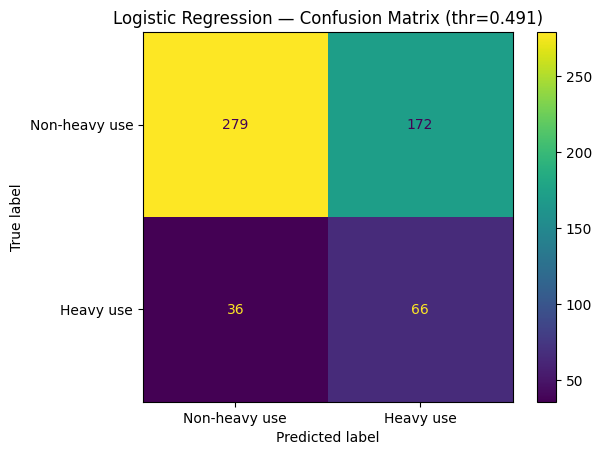

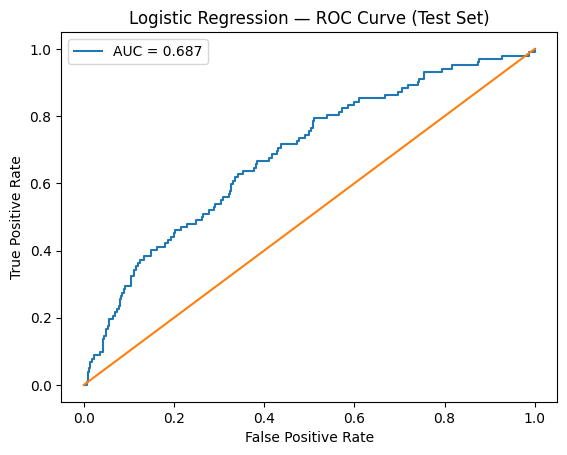

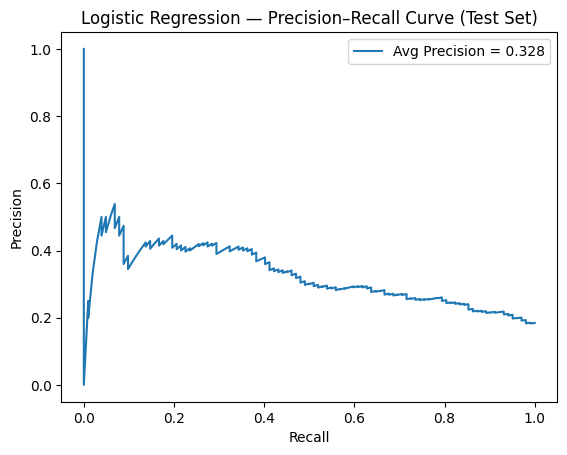

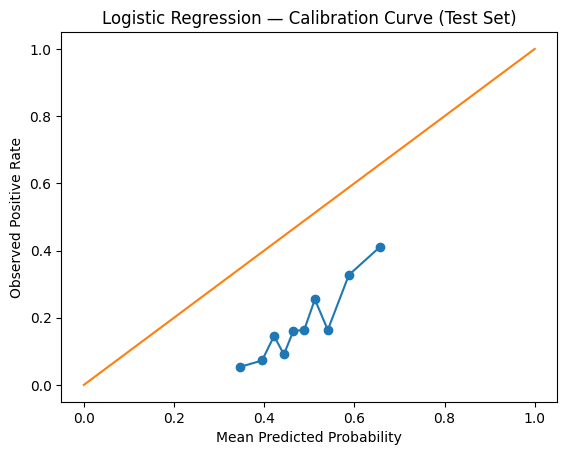

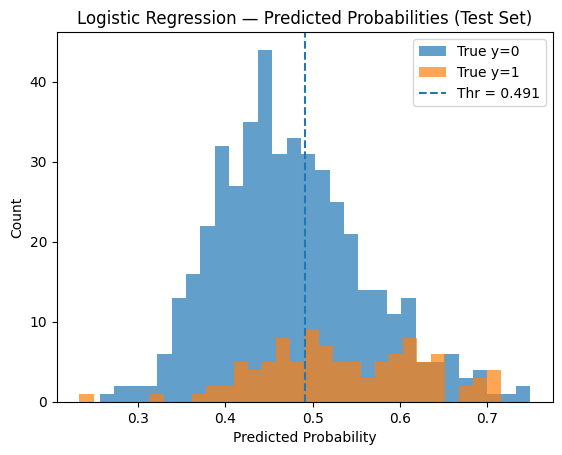


Top positive coefficients (higher risk):
                         feature      coef
0              DisciplinaryIndex  0.059203
1   Trouble_GetAlong_Teachers_W1  0.047394
6             FriendsRespect_Sex  0.045291
59            NeighborhoodType_3  0.044042
21                NotWorthLiving  0.043751
29                LessLonely_Sex  0.037549
43                    HoursTV_W1  0.034264
36                 PeerCig_Count  0.034120
16                  NightAway_W1  0.031628
64           AppearedIntoxicated  0.031580
13           SawViolentAttack_W1  0.030310
5             SexAttitudes_Index  0.029865
69         EverTried_Cigarette_Z  0.027981
17         Rev_UpsetMother_Sex_Z  0.027971
31             BuildingCondition  0.027678

Top negative coefficients (protective):
                  feature      coef
27          FriendCare_W1 -0.018424
50     NeighborhoodType_6 -0.021118
30           GroupFight_Z -0.021290
35  Bills_Payment_Ability -0.021581
63       Mother_Education -0.022018
67        Wor

In [11]:
# ============================================================
# LOGISTIC REGRESSION (L2) — TUNING + YOUDEN (CORRECT WAY)
# + FINAL TEST METRICS + FIGURES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve


# ------------------------------------------------
# 0) Copies
# ------------------------------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()
y_train_np = np.asarray(y_train)


# ------------------------------------------------
# 1) Helper: Youden threshold
# ------------------------------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]


# ------------------------------------------------
# 2) TUNED LOGISTIC REGRESSION (L2)
# ------------------------------------------------
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 25),      # explicit, transparent tuning grid
        cv=3,                           # tuning CV
        penalty="l2",
        solver="liblinear",
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        refit=True
    ))
])

# Fit FINAL model on full training set
pipe_lr.fit(X_train2, y_train)

best_C = pipe_lr.named_steps["lr"].C_[0]
print("Best C (from tuning):", best_C)


# ------------------------------------------------
# 3) YOUDEN THRESHOLD (CORRECT: TRAIN ONLY, CV=5 OOF)
# ------------------------------------------------
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob = cross_val_predict(
    pipe_lr,
    X_train2,
    y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_thr, best_j, sens, spec = youden_threshold(y_train, oof_prob)

print("\n=======================================")
print(" Youden threshold (TRAIN OOF, CV=5):", round(best_thr, 4))
print(" Youden J:", round(best_j, 4))
print(" Sensitivity:", round(sens, 4))
print(" Specificity:", round(spec, 4))
print("=======================================")


# ------------------------------------------------
# 4) FINAL TEST EVALUATION (single report)
# ------------------------------------------------
y_prob_test = pipe_lr.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)

y_pred_test = (y_prob_test >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

print("\n=======================================")
print(" LOGISTIC REGRESSION (L2) — TEST RESULTS")
print("=======================================")
print("Test AUC:", round(test_auc, 4))
print("Test PR–AUC:", round(ap, 4))
print("Threshold used (Youden):", round(best_thr, 4))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test, digits=3))


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 Colored Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Logistic Regression — Confusion Matrix (thr={best_thr:.3f})")
plt.show()


# 5.2 ROC Curve (TEST)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC Curve (Test Set)")
plt.legend()
plt.show()


# 5.3 Precision–Recall Curve (TEST)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)

plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()


# 5.4 Calibration Curve (TEST)
prob_true, prob_pred = calibration_curve(
    y_test, y_prob_test, n_bins=10, strategy="quantile"
)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Logistic Regression — Calibration Curve (Test Set)")
plt.show()


# 5.5 Probability Distributions (TEST) + threshold
y_test_np = np.asarray(y_test)

plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(best_thr, linestyle="--", label=f"Thr = {best_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Logistic Regression — Predicted Probabilities (Test Set)")
plt.legend()
plt.show()


# ------------------------------------------------
# 6) COEFFICIENTS (FINAL, INTERPRETABLE)
# ------------------------------------------------
coef = pipe_lr.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (higher risk):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective):")
print(coef_df.tail(15))


## ElasticNet


Best C (from tuning): 0.012742749857031334
Best l1_ratio (from tuning): 0.1

 Youden threshold (TRAIN OOF, CV=5): 0.4948
 Youden J: 0.2503
 Sensitivity: 0.6078
 Specificity: 0.6425

 ELASTIC NET LOGISTIC — TEST RESULTS
Test AUC: 0.6717
Test PR–AUC: 0.3114
Threshold used (Youden): 0.4948

Confusion Matrix:
 [[307 144]
 [ 39  63]]

Classification Report:
               precision    recall  f1-score   support

           0      0.887     0.681     0.770       451
           1      0.304     0.618     0.408       102

    accuracy                          0.669       553
   macro avg      0.596     0.649     0.589       553
weighted avg      0.780     0.669     0.704       553



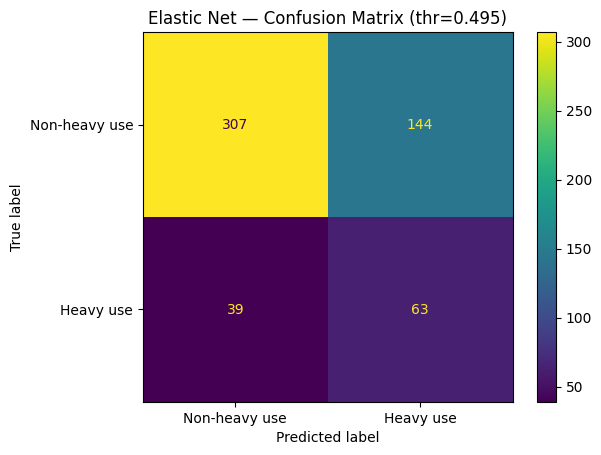

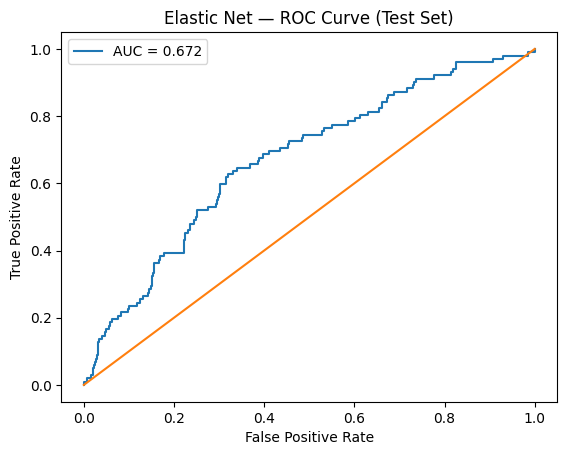

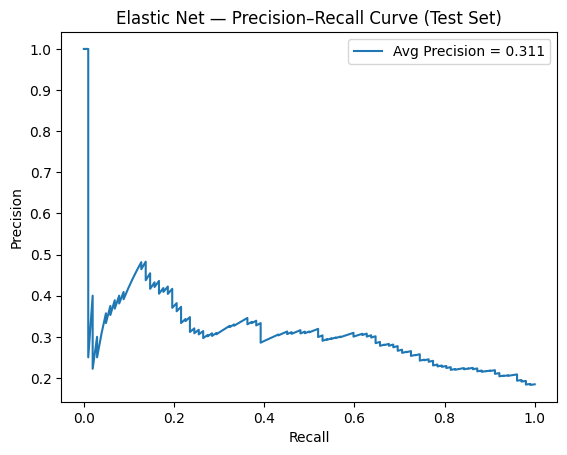

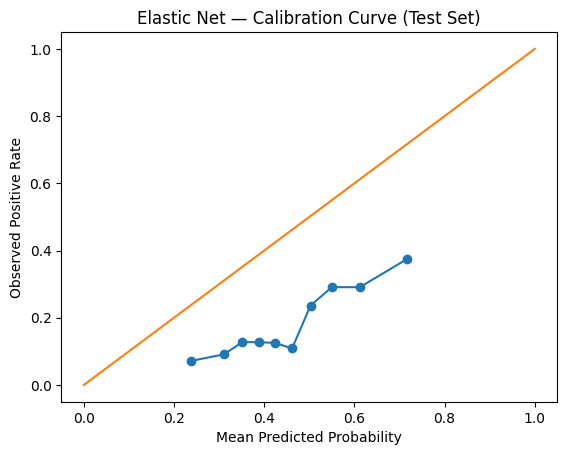

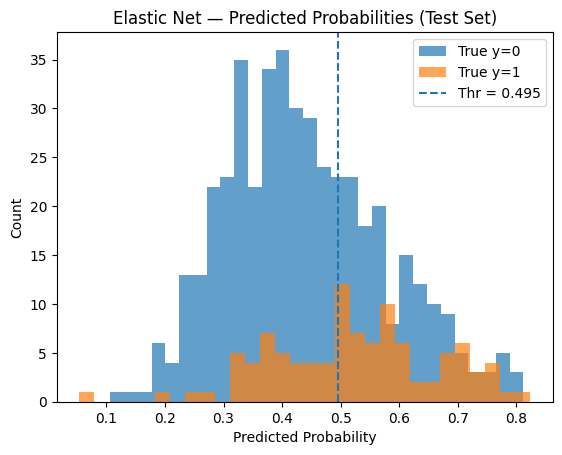


Top positive coefficients (risk factors):
                         feature      coef
0              DisciplinaryIndex  0.165492
21                NotWorthLiving  0.131129
1   Trouble_GetAlong_Teachers_W1  0.116199
6             FriendsRespect_Sex  0.113255
59            NeighborhoodType_3  0.101665
29                LessLonely_Sex  0.090179
36                 PeerCig_Count  0.082057
16                  NightAway_W1  0.078023
43                    HoursTV_W1  0.076456
69         EverTried_Cigarette_Z  0.074832
64           AppearedIntoxicated  0.071547
34              ExpectCollege_W1  0.068492
13           SawViolentAttack_W1  0.064060
17         Rev_UpsetMother_Sex_Z  0.062450
32      DroveWithoutPermission_Z  0.062197

Top negative coefficients (protective factors):
                          feature      coef
46                  ParentCare_W1 -0.035116
55           MentalDistress_Index -0.038121
67                WorkedForPay_W1 -0.052209
7              Age_FirstMarijuana -0.052272


In [9]:
# ============================================================
# ELASTIC NET LOGISTIC REGRESSION — COLLINEARITY FILTER (>0.85)
# + TUNING + YOUDEN (CORRECT WAY: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve


# ------------------------------------------------
# 0) COPY DATA
# ------------------------------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()
y_train_np = np.asarray(y_train)





# ------------------------------------------------
# 2) HELPER: YOUDEN THRESHOLD
# ------------------------------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]


# ------------------------------------------------
# 3) TUNED ELASTIC NET LOGISTIC REGRESSION
#    (tuning inside training; explicitly show C grid)
# ------------------------------------------------
pipe_en = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 20),     # explicit C grid (transparent)
        cv=3,                          # tuning CV (set 5 if you want; 3 is common for speed)
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        n_jobs=-1,
        refit=True
    ))
])

# Fit FINAL model on full training set
pipe_en.fit(X_train2, y_train)

best_C = pipe_en.named_steps["lr"].C_[0]
best_l1 = pipe_en.named_steps["lr"].l1_ratio_[0] if hasattr(pipe_en.named_steps["lr"], "l1_ratio_") else None
print("\nBest C (from tuning):", best_C)
if best_l1 is not None:
    print("Best l1_ratio (from tuning):", best_l1)


# ------------------------------------------------
# 4) YOUDEN THRESHOLD (CORRECT: TRAIN ONLY, CV=5 OOF)
# ------------------------------------------------
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob = cross_val_predict(
    pipe_en,
    X_train2,
    y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_thr, best_j, sens, spec = youden_threshold(y_train, oof_prob)

print("\n=======================================")
print(" Youden threshold (TRAIN OOF, CV=5):", round(best_thr, 4))
print(" Youden J:", round(best_j, 4))
print(" Sensitivity:", round(sens, 4))
print(" Specificity:", round(spec, 4))
print("=======================================")


# ------------------------------------------------
# 5) FINAL TEST EVALUATION (single report)
# ------------------------------------------------
y_prob_test = pipe_en.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)

y_pred_test = (y_prob_test >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

print("\n=======================================")
print(" ELASTIC NET LOGISTIC — TEST RESULTS")
print("=======================================")
print("Test AUC:", round(test_auc, 4))
print("Test PR–AUC:", round(ap, 4))
print("Threshold used (Youden):", round(best_thr, 4))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test, digits=3))


# ============================================================
# 6) FIGURES
# ============================================================

# 6.1 Colored Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Elastic Net — Confusion Matrix (thr={best_thr:.3f})")
plt.show()

# 6.2 ROC Curve (TEST)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Elastic Net — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 6.3 Precision–Recall Curve (TEST)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Elastic Net — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 6.4 Calibration Curve (TEST)
prob_true, prob_pred = calibration_curve(
    y_test, y_prob_test, n_bins=10, strategy="quantile"
)
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Elastic Net — Calibration Curve (Test Set)")
plt.show()

# 6.5 Probability Distributions (TEST) + threshold
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(best_thr, linestyle="--", label=f"Thr = {best_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Elastic Net — Predicted Probabilities (Test Set)")
plt.legend()
plt.show()


# ------------------------------------------------
# 7) COEFFICIENTS (FINAL, INTERPRETABLE OUTPUT)
# ------------------------------------------------
coef = pipe_en.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (risk factors):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective factors):")
print(coef_df.tail(15))


## RandomForest 

Running RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6345
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'min_impurity_decrease': 0.0001, 'max_features': 'log2', 'max_depth': None, 'class_weight': None, 'bootstrap': True}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.1814
Youden J (train OOF): 0.2246
Sensitivity (TPR) @ thr: 0.6961
Specificity (TNR) @ thr: 0.5285

RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6690
Test PR–AUC : 0.3140
Threshold used (Youden, from train OOF): 0.1814

Accuracy : 0.5949
Precision: 0.2636
Recall   : 0.6667
F1-score : 0.3778

Confusion Matrix (Test):
 [[261 190]
 [ 34  68]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.884746  0.578714  0.699732  451.000000
1              0.263566  0.666667  0.377778  102.000000
accuracy       0.594937  0.594937  0.594937   

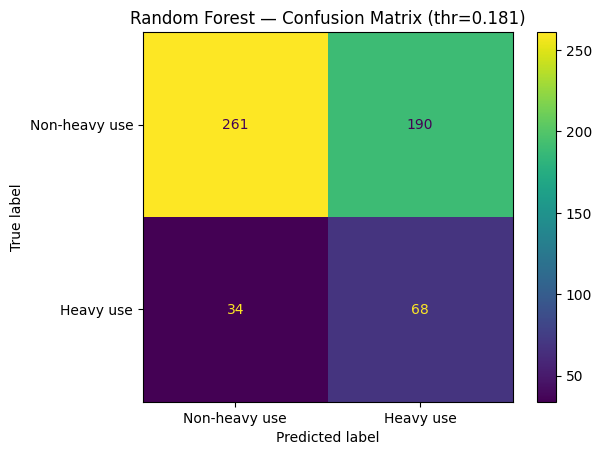

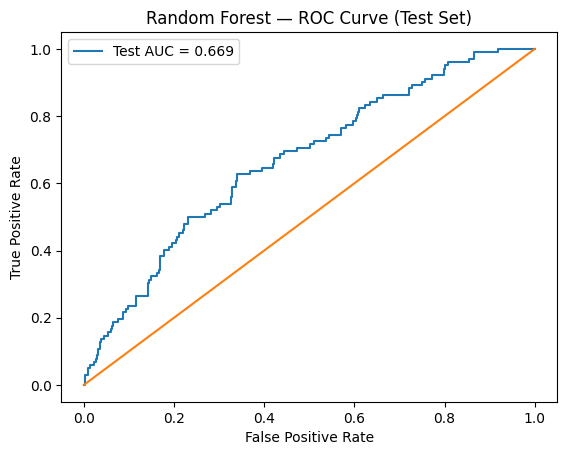

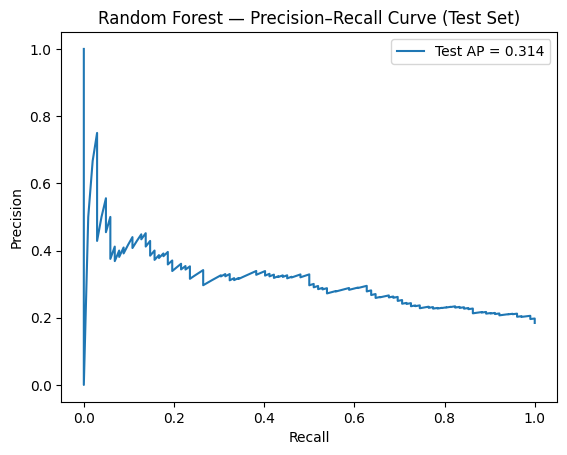

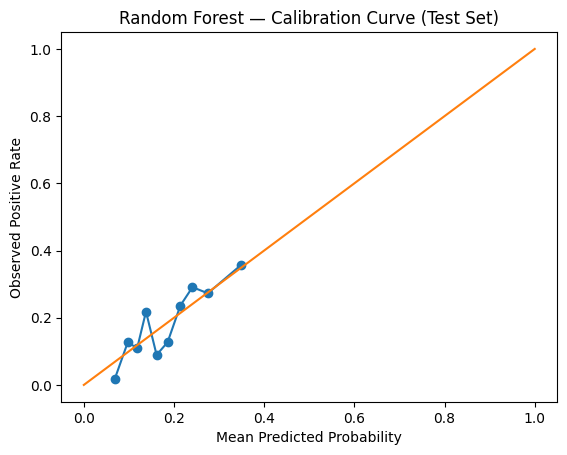

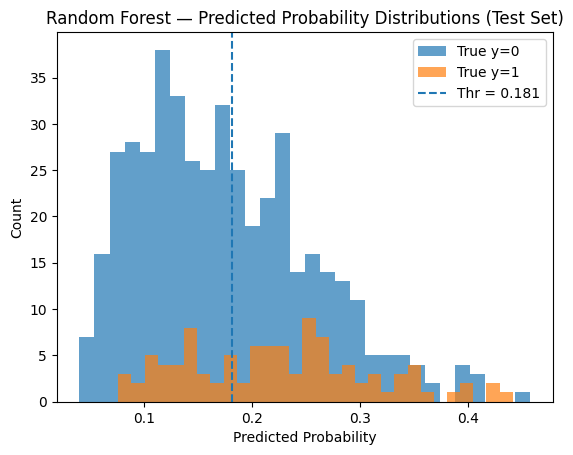


Best RF estimator:
RandomForestClassifier(max_features='log2', min_impurity_decrease=0.0001,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=500, n_jobs=-1, random_state=42)


In [11]:
# ============================================================
# RANDOM FOREST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

# Tuning CV (your preference)
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Youden threshold CV (train-only, more stable)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ----------------------------
# 2) TUNING SPACE (your grid + a couple of useful additions)
#    Additions:
#    - bootstrap: can affect calibration/variance
#    - min_impurity_decrease: small regularization knob (optional)
# ----------------------------
param_dist = {
    'n_estimators': [300, 500, 800, 1200, 1600],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.8, None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'bootstrap': [True, False],
    'min_impurity_decrease': [0.0, 0.0001, 0.001]
}

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running RandomizedSearchCV...")
rs.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs.best_score_, 4))
print("Best Parameters:")
print(rs.best_params_)

best_rf = rs.best_estimator_  # best hyperparameters (refit=True by default)

# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY)
#    - compute OOF probabilities on TRAIN ONLY using CV=5
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_rf,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))

# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_rf.fit(X_train2, y_train)

y_prob_test = best_rf.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)

# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Random Forest — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Random Forest — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Random Forest — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest RF estimator:")
print(best_rf)


## Catboost

Running CatBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6362
Best Parameters (CatBoost):
{'subsample': 0.9, 'rsm': 0.6, 'random_strength': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 400, 'depth': 4, 'class_weights': [1, 5], 'bagging_temperature': 0}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.4985
Youden J (train OOF): 0.2331
Sensitivity (TPR) @ thr: 0.6765
Specificity (TNR) @ thr: 0.5566

CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6868
Test PR–AUC : 0.3296
Threshold used (Youden, from train OOF): 0.4985

Accuracy : 0.6148
Precision: 0.2771
Recall   : 0.6765
F1-score : 0.3932

Confusion Matrix (Test):
 [[271 180]
 [ 33  69]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.891447  0.600887  0.717881  451.000000
1              0.277108  0.676471  0.393162  102.000000
accuracy       0.614828  0.614828  0.6148

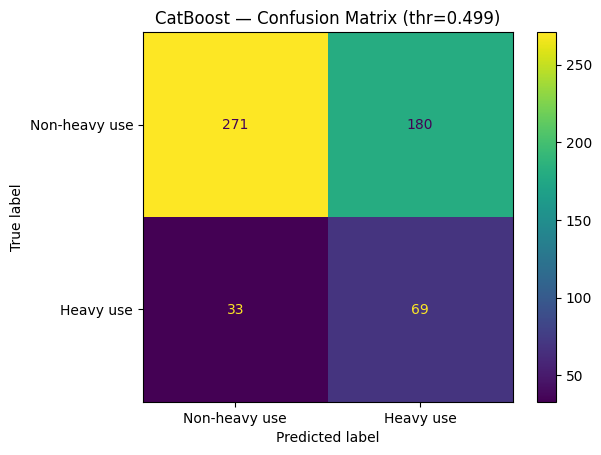

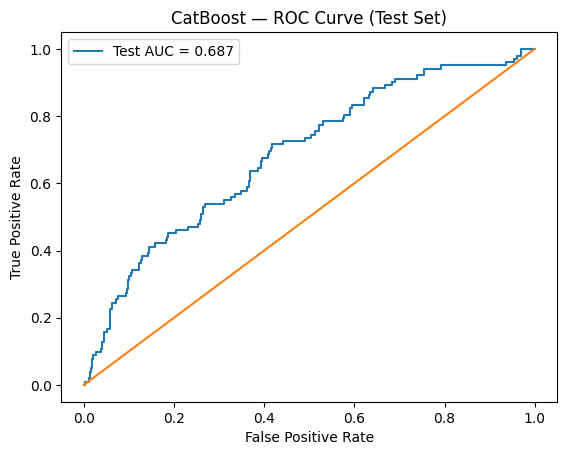

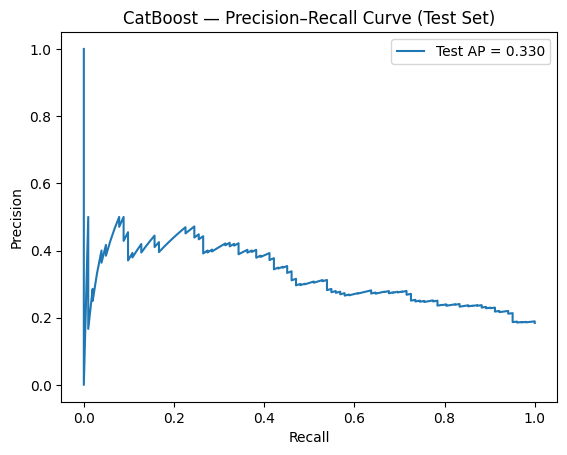

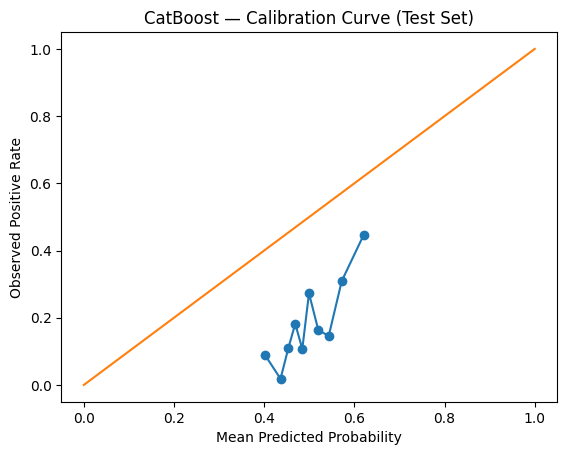

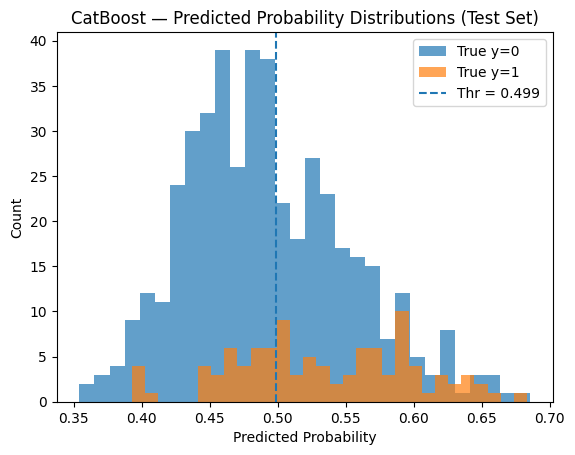


Best CatBoost estimator:


In [12]:
# ============================================================
# CATBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # tuning CV
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # threshold CV

# ----------------------------
# 1) BASE MODEL
# ----------------------------
cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

# ----------------------------
# 2) TUNING SPACE
#    Your grid + a couple of useful additions for generalization:
#    - rsm (feature subsampling) helps reduce overfit
#    - bagging_temperature controls bootstrap strength (esp. good for CatBoost)
# ----------------------------
param_dist_cat = {
    "iterations": [400, 800, 1200, 1600],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9, 12, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5, 10],
    "bagging_temperature": [0, 1, 5, 10],
    "rsm": [0.6, 0.8, 1.0],
    # your class-weights tuning (fine)
    "class_weights": [[1, 3], [1, 5], [1, 7], [1, 10]]
}

rs_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist_cat,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running CatBoost RandomizedSearchCV...")
rs_cat.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_cat.best_score_, 4))
print("Best Parameters (CatBoost):")
print(rs_cat.best_params_)

best_cat = rs_cat.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_cat,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_cat.fit(X_train2, y_train)

y_prob_test = best_cat.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_cat.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"CatBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CatBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("CatBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("CatBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest CatBoost estimator:")
print(best_cat)


## XGBoost

Running XGBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6193
Best Parameters (XGBoost):
{'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 12, 'max_depth': 3, 'max_delta_step': 1, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 1.0}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.4576
Youden J (train OOF): 0.2255
Sensitivity (TPR) @ thr: 0.6667
Specificity (TNR) @ thr: 0.5588

XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6564
Test PR–AUC : 0.3157
Threshold used (Youden, from train OOF): 0.4576

Accuracy : 0.5986
Precision: 0.2619
Recall   : 0.6471
F1-score : 0.3729

Confusion Matrix (Test):
 [[265 186]
 [ 36  66]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.880399  0.587583  0.704787  451.000000
1              0.261905  0.647059  0.372881  102.000000
accuracy       0.598553  0

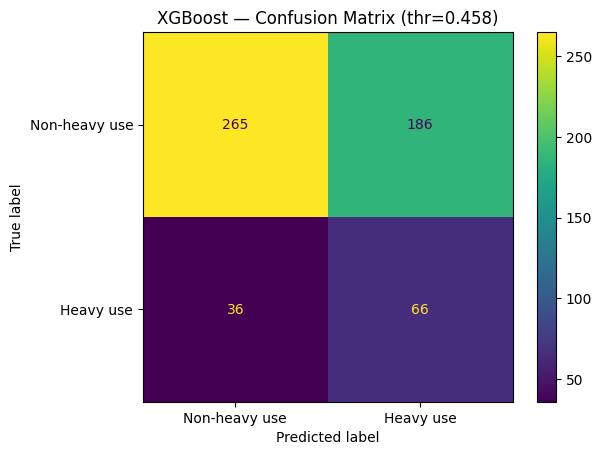

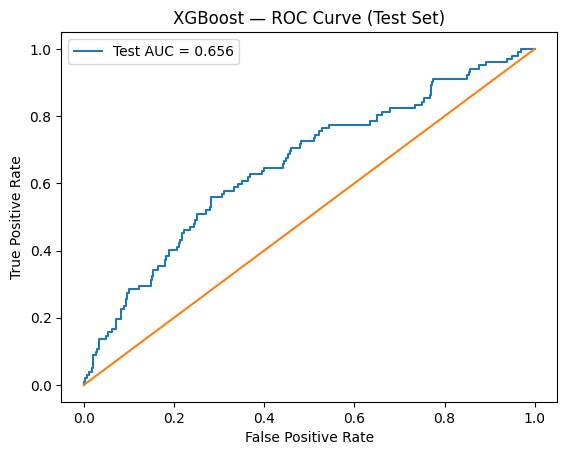

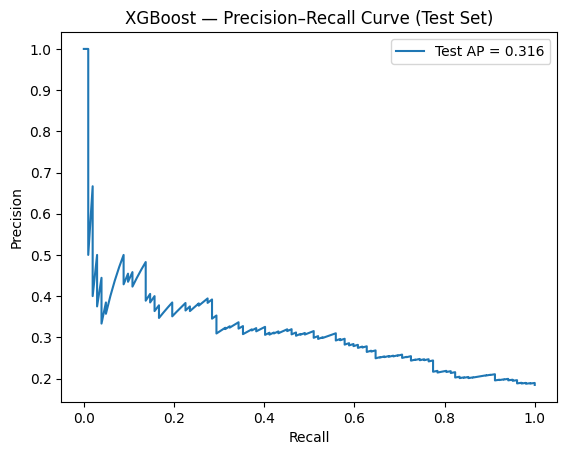

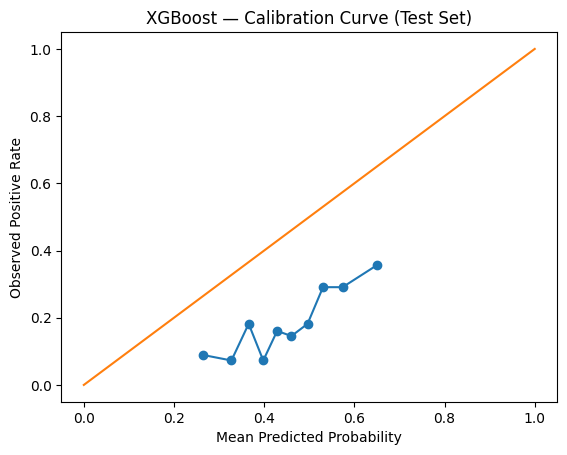

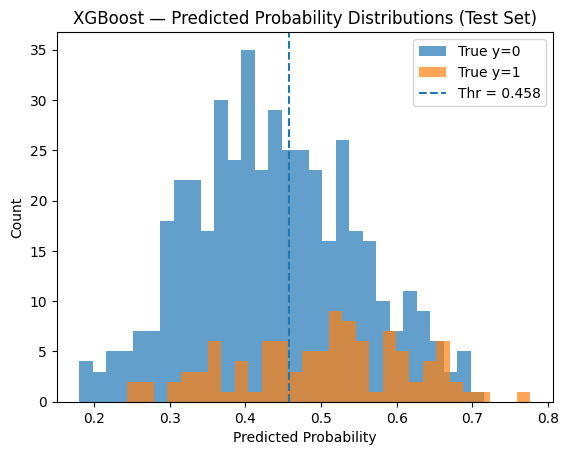


Best XGBoost estimator:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=1,
              max_depth=3, max_leaves=None, min_child_weight=12, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)


In [13]:
# ============================================================
# XGBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) COPIES + IMBALANCE RATIO
# ----------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = neg / pos

RANDOM_STATE = 42
cv_tune   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",          # stable for training; AUC used in CV scoring
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos
)

# ----------------------------
# 2) TUNING SPACE (your grid + useful additions)
#    Additions:
#    - reg_lambda & reg_alpha already included (good)
#    - min_child_weight already included (good)
#    - max_delta_step sometimes stabilizes imbalanced logistic loss (optional)
# ----------------------------
param_dist_xgb = {
    "n_estimators": [300, 500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "max_delta_step": [0, 1, 5]     # optional stabilizer for imbalance
}

rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running XGBoost RandomizedSearchCV...")
rs_xgb.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_xgb.best_score_, 4))
print("Best Parameters (XGBoost):")
print(rs_xgb.best_params_)

best_xgb = rs_xgb.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_xgb,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_xgb.fit(X_train2, y_train)

y_prob_test = best_xgb.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_xgb.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"XGBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("XGBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("XGBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest XGBoost estimator:")
print(best_xgb)


X_bg_np dtype: float32
X_test_np dtype: float32


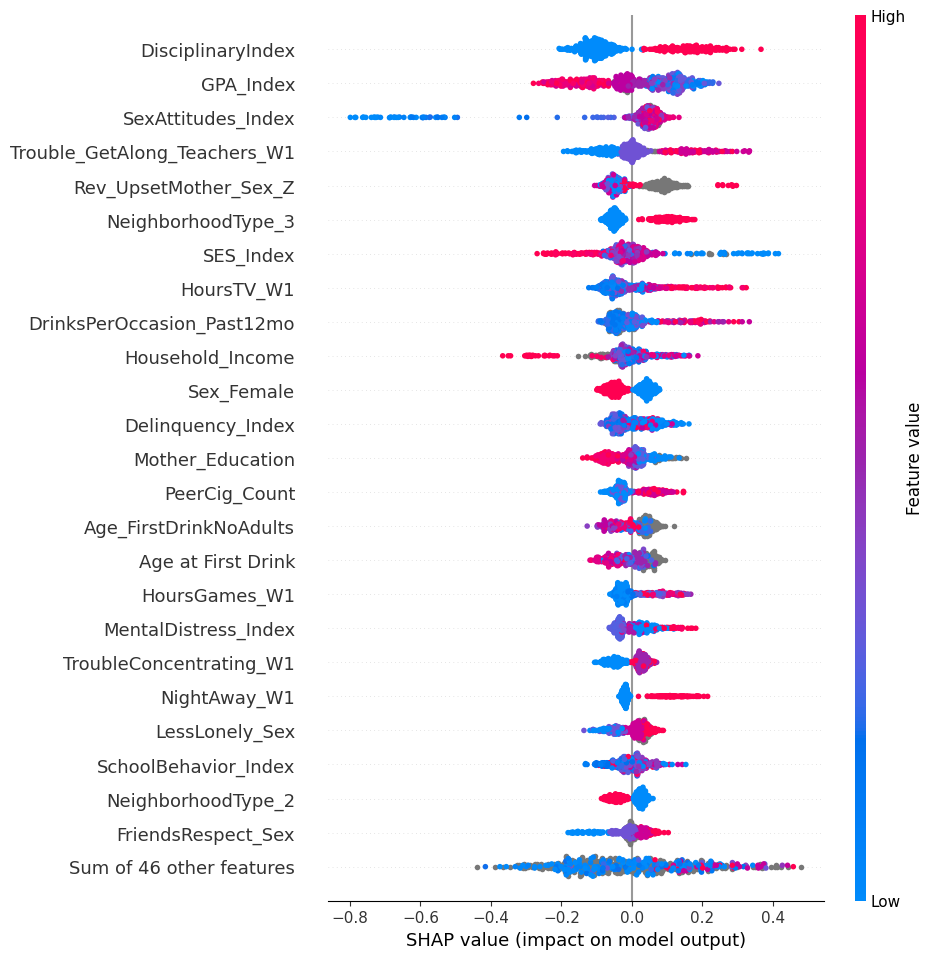

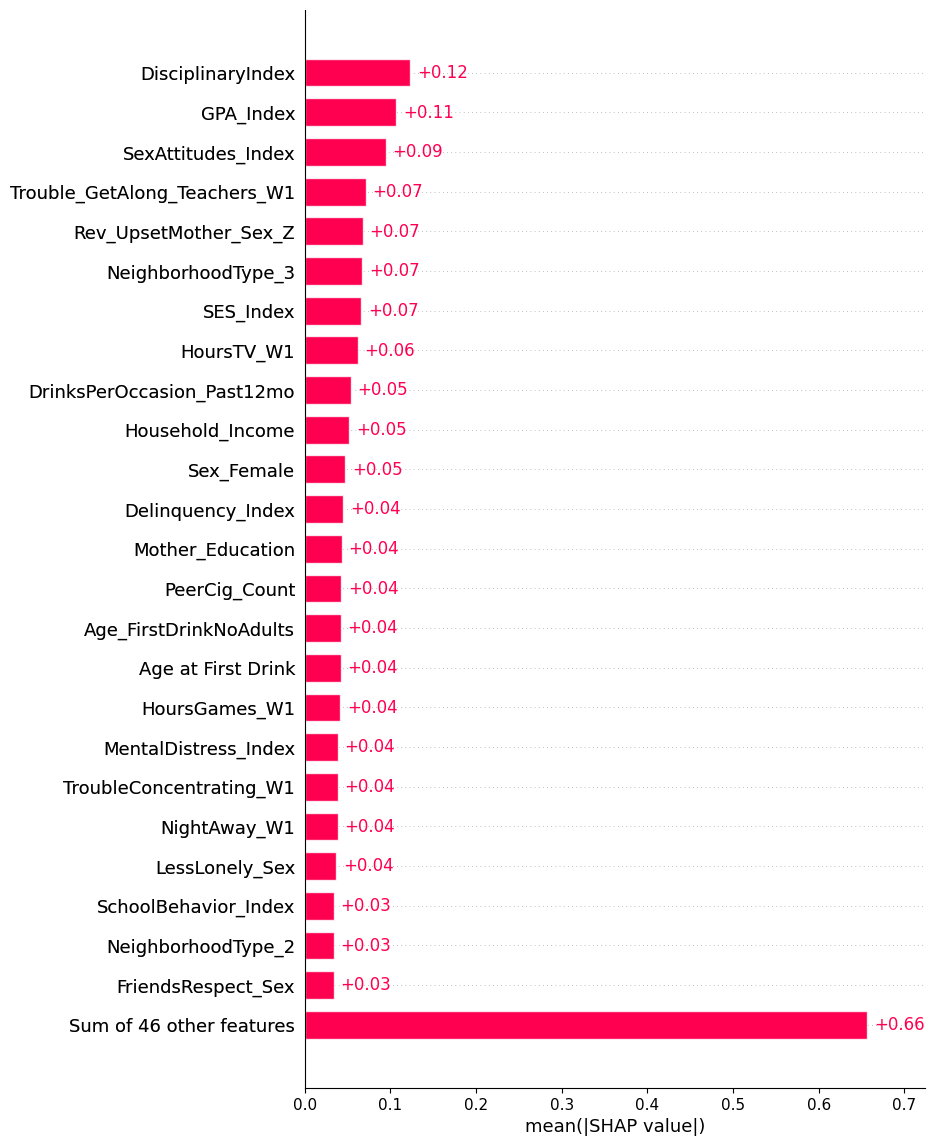

Top SHAP features: ['DisciplinaryIndex', 'GPA_Index', 'SexAttitudes_Index', 'Trouble_GetAlong_Teachers_W1', 'Rev_UpsetMother_Sex_Z', 'NeighborhoodType_3', 'SES_Index', 'HoursTV_W1', 'DrinksPerOccasion_Past12mo', 'Household_Income']


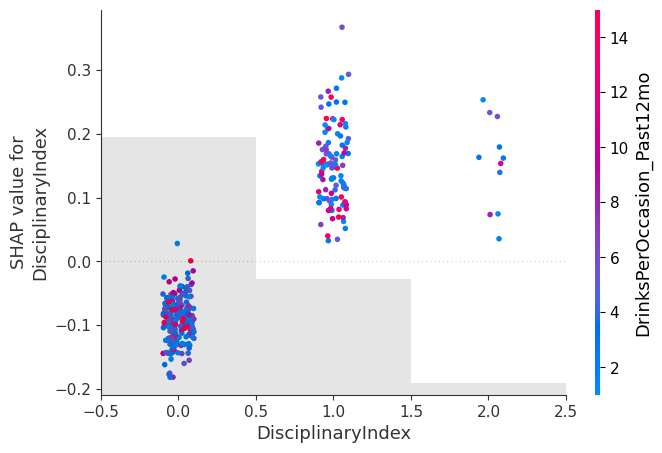

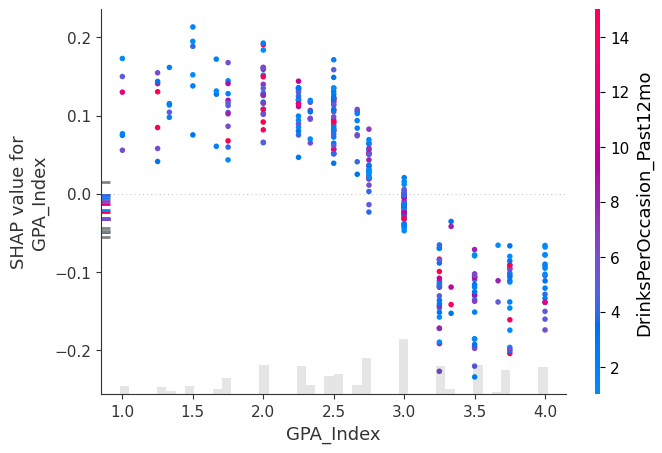

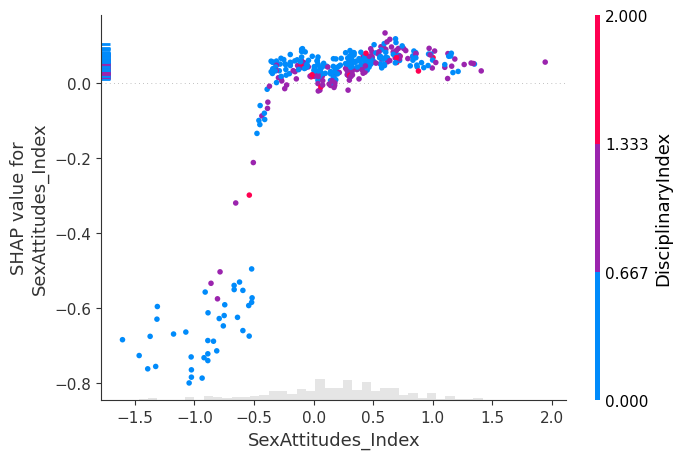

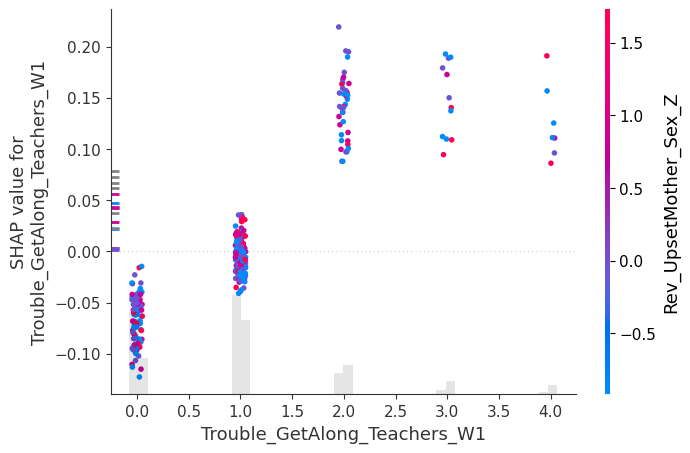

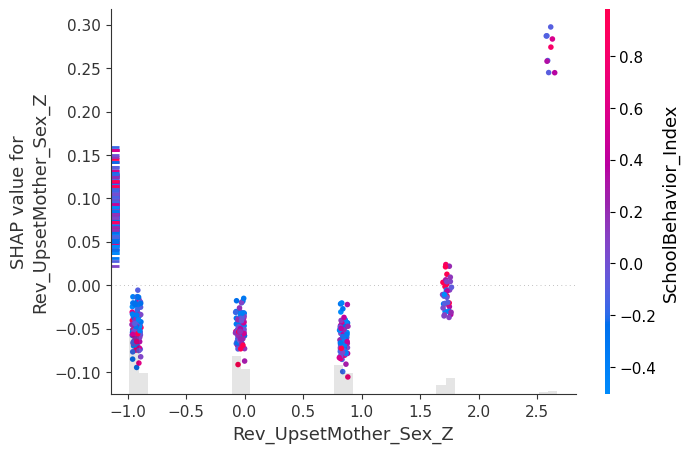

Explaining test row index: 502


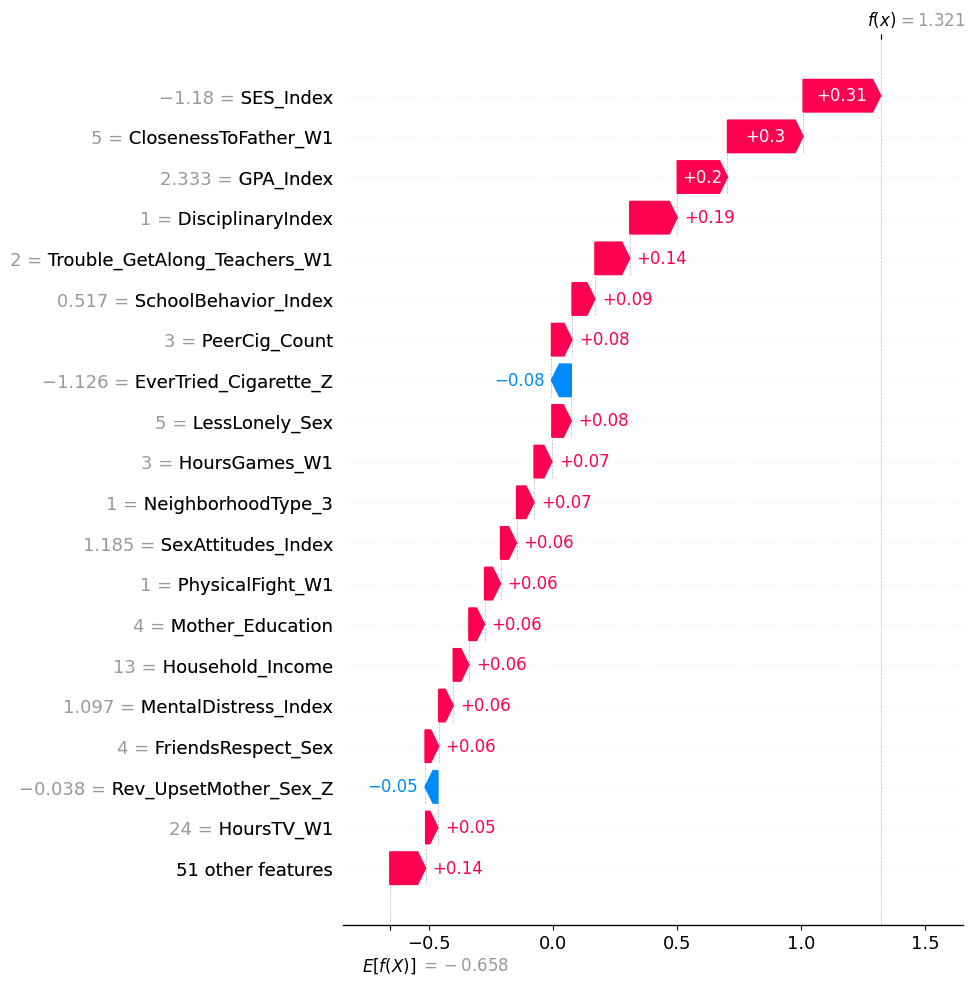

In [13]:
# ============================
# SHAP analysis for best_xgb
# ============================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
X_train_xgb=X_train.copy()
X_test_xgb=X_test.copy()
# 0) Make sure X_* are DataFrames (keeps feature names for plots)
if not isinstance(X_train_xgb, pd.DataFrame):
    X_train_xgb = pd.DataFrame(X_train_xgb)
if not isinstance(X_test_xgb, pd.DataFrame):
    X_test_xgb = pd.DataFrame(X_test_xgb)

# (Optional but recommended) background sample for speed/stability
bg_size = min(500, len(X_train_xgb))
X_bg = X_train_xgb.sample(bg_size, random_state=42)


import numpy as np
import shap

feature_names = X_train_xgb.columns.tolist()

# 1) Convert bool -> int, then force everything to float32
def force_float32(df):
    df = df.copy()
    bool_cols = df.select_dtypes(include=["bool"]).columns
    df[bool_cols] = df[bool_cols].astype(np.int8)
    return df.astype(np.float32)

X_train_shap = force_float32(X_train_xgb)
X_test_shap  = force_float32(X_test_xgb)

# 2) Background sample
bg_size = min(200, len(X_train_shap))
X_bg = X_train_shap.sample(bg_size, random_state=42)

# 3) Convert to numpy float32 (NOW it won't be object)
X_bg_np   = X_bg.to_numpy(dtype=np.float32)
X_test_np = X_test_shap.to_numpy(dtype=np.float32)

print("X_bg_np dtype:", X_bg_np.dtype)
print("X_test_np dtype:", X_test_np.dtype)

# 4) SHAP
explainer = shap.Explainer(best_xgb, X_bg_np, feature_names=feature_names)
shap_values = explainer(X_test_np)

shap.plots.beeswarm(shap_values, max_display=25)




# (Alternative global view: mean(|SHAP|) bar)
shap.plots.bar(shap_values, max_display=25)

# ---------------------------------------------------------
# B) DEPENDENCE: top features (scatter plots)
# ---------------------------------------------------------
# Get top features by mean absolute SHAP
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]
top_features = X_test_xgb.columns[top_idx].tolist()

print("Top SHAP features:", top_features)

# Dependence plots for top features
for feat in top_features[:5]:
    shap.plots.scatter(shap_values[:, feat], color=shap_values)

# ---------------------------------------------------------
# C) LOCAL: explain a single prediction
# ---------------------------------------------------------
# Choose an instance index (e.g., highest predicted risk)
idx = int(np.argmax(best_xgb.predict_proba(X_test_xgb)[:, 1]))
print("Explaining test row index:", idx)

# Waterfall plot for that instance
shap.plots.waterfall(shap_values[idx], max_display=20)

# Force plot (interactive in notebooks; may need JS init)
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values.values[idx, :],
    X_test_xgb.iloc[idx, :],
)

# ---------------------------------------------------------
# D) (Optional) SHAP values table export
# ---------------------------------------------------------
shap_df = pd.DataFrame(shap_values.values, columns=X_test_xgb.columns)
shap_df["pred_prob"] = best_xgb.predict_proba(X_test_xgb)[:, 1]
shap_df["y_true"] = np.array(y_test)

# Save if you want
# shap_df.to_csv("shap_values_test.csv", index=False)


In [20]:
# SHAP values array: (n_samples, n_features)
S = shap_values.values

# Optional but recommended: standardize
from sklearn.preprocessing import StandardScaler
S_scaled = StandardScaler().fit_transform(S)


In [21]:
from sklearn.cluster import KMeans

k = 3  # start here
kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
archetypes = kmeans.fit_predict(S_scaled)


In [22]:
df_archetypes = X_test_xgb.copy()
df_archetypes["archetype"] = archetypes
df_archetypes["pred_prob"] = best_xgb.predict_proba(X_test_xgb)[:, 1]


In [23]:
import pandas as pd
import numpy as np

archetype_profiles = (
    pd.DataFrame(S, columns=feature_names)
      .assign(archetype=archetypes)
      .groupby("archetype")
      .mean()
)

archetype_profiles


,DisciplinaryIndex,Trouble_GetAlong_Teachers_W1,SchoolBehavior_Index,Sex_Female,GPA_Index,SexAttitudes_Index,FriendsRespect_Sex,Age_FirstMarijuana,Lifetime_Marijuana,Delinquency_Index,...,HangoutFriends_W1,TroubleConcentrating_W1,ClosenessToFather_W1,Mother_Education,AppearedIntoxicated,WantLeaveHome_W1,DrinkWithoutAdults_Z,WorkedForPay_W1,NeighborhoodType_2,EverTried_Cigarette_Z
archetype,,,,,,,,,,,,,,,,,,,,,
0,0.077153,0.052060,0.013507,0.010030,0.052860,0.036115,0.008577,0.010832,0.011696,0.011923,...,0.003414,0.010422,-0.002989,0.016353,0.0,0.007925,0.003933,-0.000356,-0.003307,0.009402
1,-0.051067,0.006407,-0.010258,-0.003776,-0.024240,0.049132,0.003673,-0.003276,-0.002435,0.004338,...,-0.000084,-0.010646,-0.008845,-0.008701,0.0,-0.017795,0.002940,0.002133,0.003346,-0.017750
2,-0.042976,-0.010913,-0.005179,-0.012467,0.003189,-0.078872,-0.018130,0.000067,-0.010200,-0.005763,...,-0.000213,-0.002251,-0.008728,-0.021549,0.0,-0.000750,0.008758,-0.002864,-0.001557,0.006553



Archetype 0


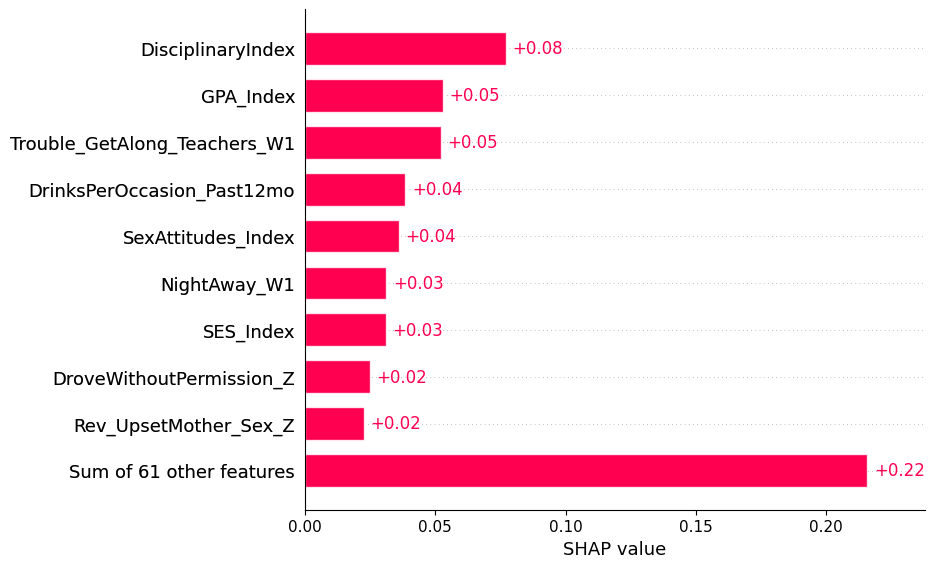


Archetype 1


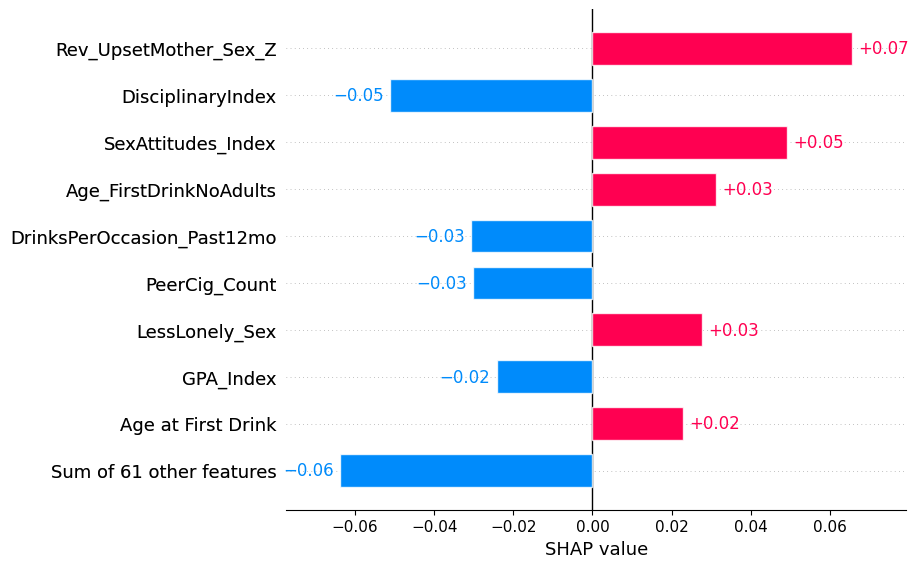


Archetype 2


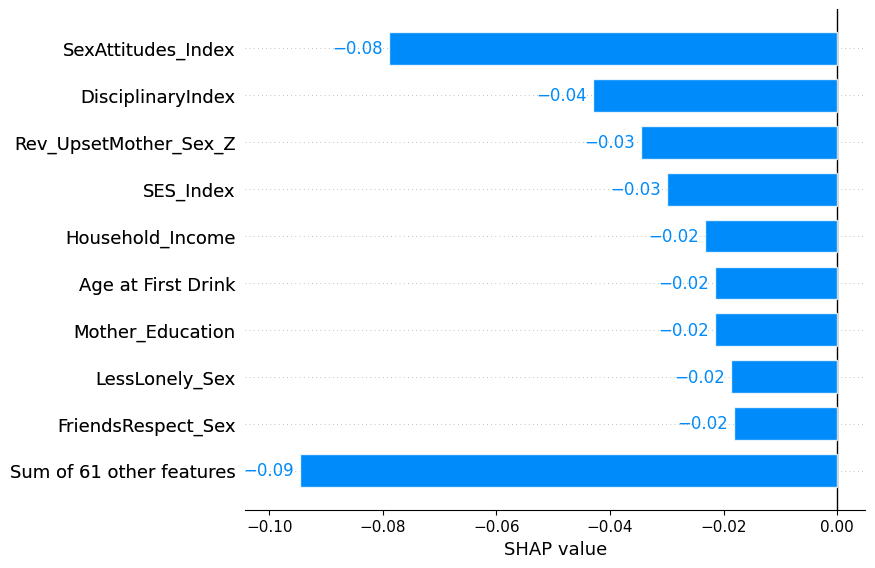

In [24]:
for a in sorted(df_archetypes["archetype"].unique()):
    print(f"\nArchetype {a}")
    shap.plots.bar(
        shap.Explanation(
            values=archetype_profiles.loc[a].values,
            feature_names=feature_names
        ),
        max_display=10
    )


In [25]:
df_archetypes.groupby("archetype")["pred_prob"].describe()


,count,mean,std,min,25%,50%,75%,max
archetype,,,,,,,,
0,148.0,0.482030,0.108835,0.233714,0.407122,0.477942,0.564681,0.789360
1,183.0,0.349812,0.119260,0.119396,0.255748,0.332429,0.430014,0.657739
2,222.0,0.271944,0.096591,0.092031,0.199225,0.267521,0.333912,0.571584


## cutoff 3

In [14]:
df2 = df2[df2["DaysMarijuanaPast12M_W4"].notna()].copy()
df2["heavy_smoker"] = (df2["DaysMarijuanaPast12M_W4"] >3 ).astype(int)

y = df2["heavy_smoker"]

X = df2.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


## L2 Logistic

Best C (from tuning): 0.001

 Youden threshold (TRAIN OOF, CV=5): 0.4882
 Youden J: 0.1885
 Sensitivity: 0.6508
 Specificity: 0.5377

 LOGISTIC REGRESSION (L2) — TEST RESULTS
Test AUC: 0.6751
Test PR–AUC: 0.4
Threshold used (Youden): 0.4882

Confusion Matrix:
 [[228 192]
 [ 34  99]]

Classification Report:
               precision    recall  f1-score   support

           0      0.870     0.543     0.669       420
           1      0.340     0.744     0.467       133

    accuracy                          0.591       553
   macro avg      0.605     0.644     0.568       553
weighted avg      0.743     0.591     0.620       553



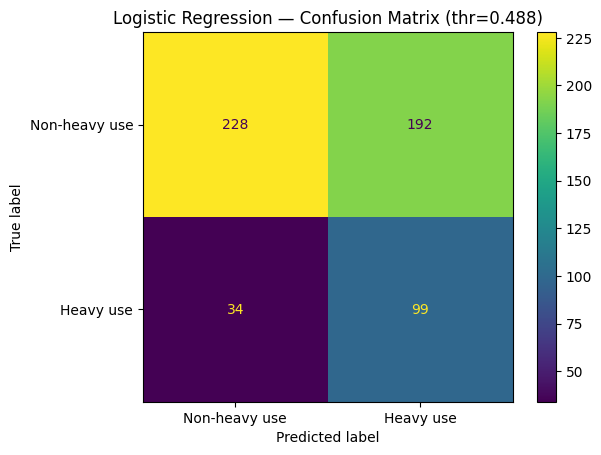

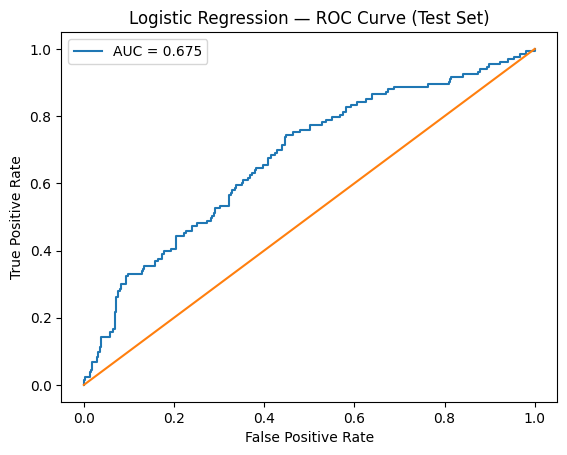

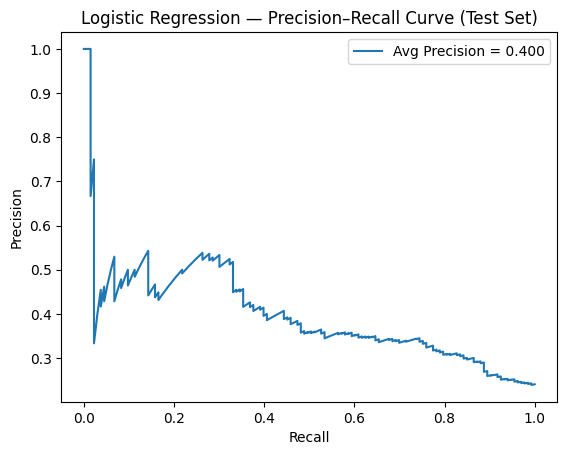

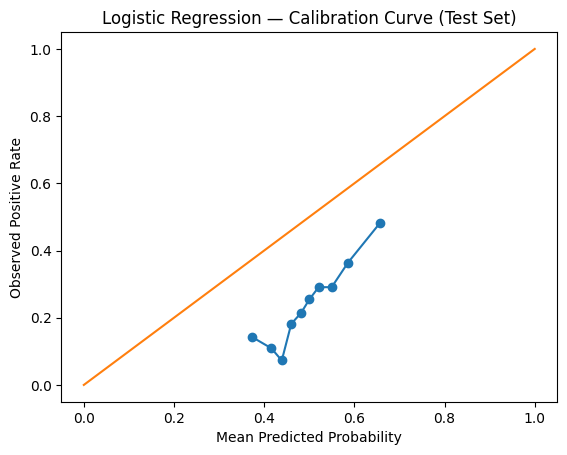

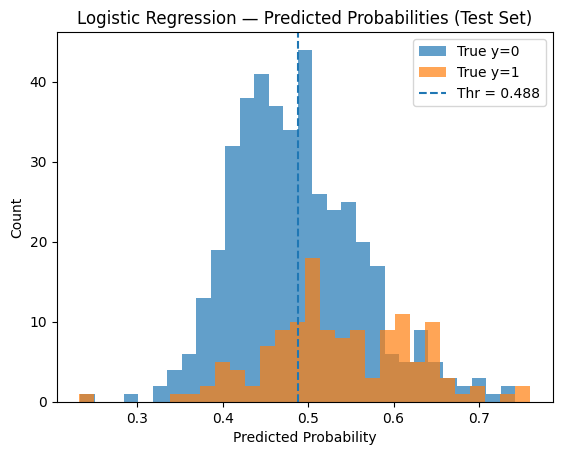


Top positive coefficients (higher risk):
                         feature      coef
0              DisciplinaryIndex  0.044403
28           DrugsAvailable_Home  0.040896
6             FriendsRespect_Sex  0.036450
1   Trouble_GetAlong_Teachers_W1  0.034979
10              PhysicalFight_W1  0.033546
49     ParentalSupervision_Index  0.029363
52              SuicidalIdeation  0.029265
36                 PeerCig_Count  0.028374
26               SchoolExpulsion  0.025552
17         Rev_UpsetMother_Sex_Z  0.025532
21                NotWorthLiving  0.025037
59            NeighborhoodType_3  0.024227
69         EverTried_Cigarette_Z  0.023444
5             SexAttitudes_Index  0.022388
23              Age_FirstCocaine  0.021219

Top negative coefficients (protective):
                  feature      coef
24         TeacherCare_W1 -0.016600
25              SES_Index -0.017267
18   ClosenessToMother_W1 -0.019730
14          Support_Index -0.021809
7      Age_FirstMarijuana -0.022739
68     Neighb

In [16]:
# ============================================================
# LOGISTIC REGRESSION (L2) — TUNING + YOUDEN (CORRECT WAY)
# + FINAL TEST METRICS + FIGURES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve


# ------------------------------------------------
# 0) Copies
# ------------------------------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()
y_train_np = np.asarray(y_train)


# ------------------------------------------------
# 1) Helper: Youden threshold
# ------------------------------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]


# ------------------------------------------------
# 2) TUNED LOGISTIC REGRESSION (L2)
# ------------------------------------------------
pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 25),      # explicit, transparent tuning grid
        cv=3,                           # tuning CV
        penalty="l2",
        solver="liblinear",
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        refit=True
    ))
])

# Fit FINAL model on full training set
pipe_lr.fit(X_train2, y_train)

best_C = pipe_lr.named_steps["lr"].C_[0]
print("Best C (from tuning):", best_C)


# ------------------------------------------------
# 3) YOUDEN THRESHOLD (CORRECT: TRAIN ONLY, CV=5 OOF)
# ------------------------------------------------
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob = cross_val_predict(
    pipe_lr,
    X_train2,
    y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_thr, best_j, sens, spec = youden_threshold(y_train, oof_prob)

print("\n=======================================")
print(" Youden threshold (TRAIN OOF, CV=5):", round(best_thr, 4))
print(" Youden J:", round(best_j, 4))
print(" Sensitivity:", round(sens, 4))
print(" Specificity:", round(spec, 4))
print("=======================================")


# ------------------------------------------------
# 4) FINAL TEST EVALUATION (single report)
# ------------------------------------------------
y_prob_test = pipe_lr.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)

y_pred_test = (y_prob_test >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

print("\n=======================================")
print(" LOGISTIC REGRESSION (L2) — TEST RESULTS")
print("=======================================")
print("Test AUC:", round(test_auc, 4))
print("Test PR–AUC:", round(ap, 4))
print("Threshold used (Youden):", round(best_thr, 4))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test, digits=3))


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 Colored Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Logistic Regression — Confusion Matrix (thr={best_thr:.3f})")
plt.show()


# 5.2 ROC Curve (TEST)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — ROC Curve (Test Set)")
plt.legend()
plt.show()


# 5.3 Precision–Recall Curve (TEST)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)

plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Logistic Regression — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()


# 5.4 Calibration Curve (TEST)
prob_true, prob_pred = calibration_curve(
    y_test, y_prob_test, n_bins=10, strategy="quantile"
)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Logistic Regression — Calibration Curve (Test Set)")
plt.show()


# 5.5 Probability Distributions (TEST) + threshold
y_test_np = np.asarray(y_test)

plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(best_thr, linestyle="--", label=f"Thr = {best_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Logistic Regression — Predicted Probabilities (Test Set)")
plt.legend()
plt.show()


# ------------------------------------------------
# 6) COEFFICIENTS (FINAL, INTERPRETABLE)
# ------------------------------------------------
coef = pipe_lr.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (higher risk):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective):")
print(coef_df.tail(15))


## ElasticNet


Best C (from tuning): 0.012742749857031334
Best l1_ratio (from tuning): 0.1

 Youden threshold (TRAIN OOF, CV=5): 0.4789
 Youden J: 0.1721
 Sensitivity: 0.6256
 Specificity: 0.5465

 ELASTIC NET LOGISTIC — TEST RESULTS
Test AUC: 0.6689
Test PR–AUC: 0.3768
Threshold used (Youden): 0.4789

Confusion Matrix:
 [[242 178]
 [ 40  93]]

Classification Report:
               precision    recall  f1-score   support

           0      0.858     0.576     0.689       420
           1      0.343     0.699     0.460       133

    accuracy                          0.606       553
   macro avg      0.601     0.638     0.575       553
weighted avg      0.734     0.606     0.634       553



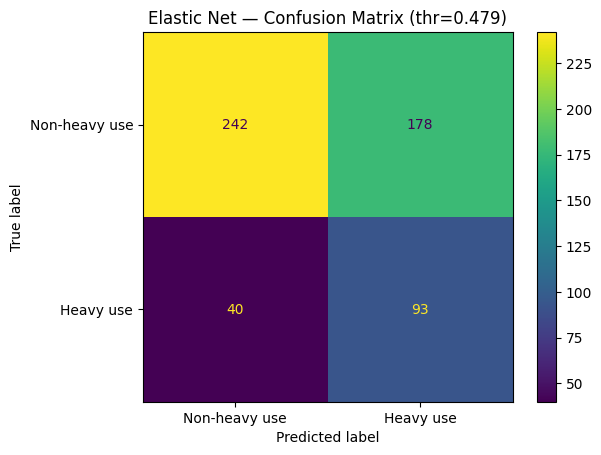

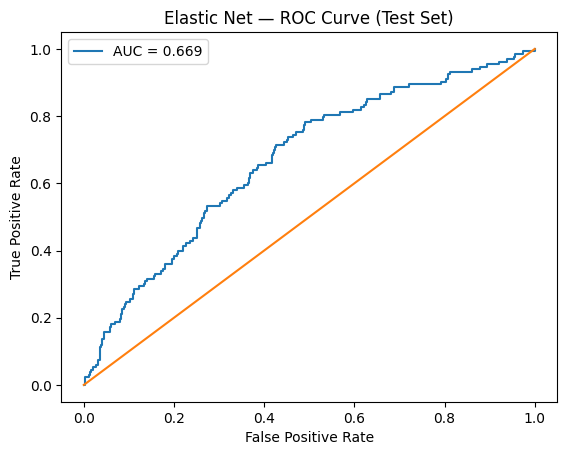

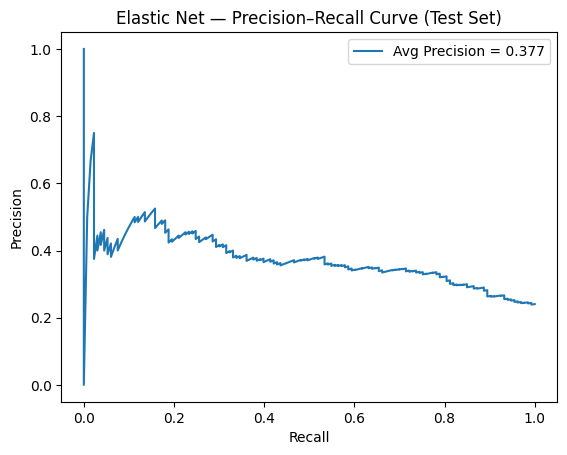

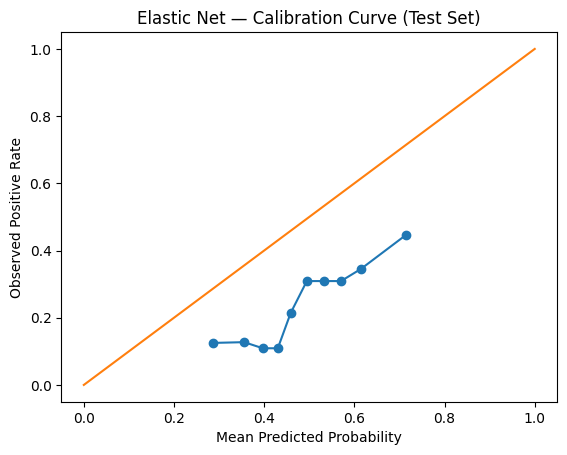

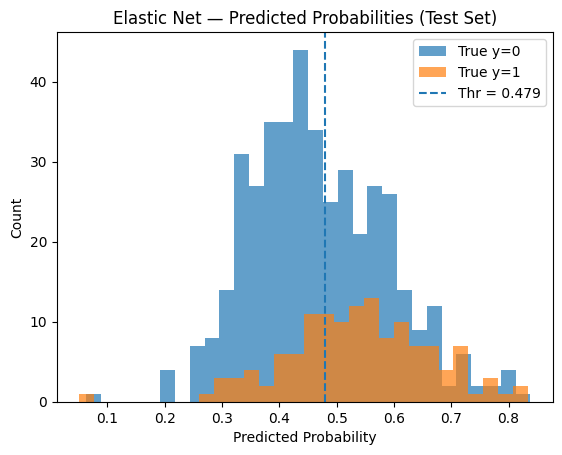


Top positive coefficients (risk factors):
                         feature      coef
0              DisciplinaryIndex  0.105481
28           DrugsAvailable_Home  0.093752
52              SuicidalIdeation  0.084318
1   Trouble_GetAlong_Teachers_W1  0.079122
6             FriendsRespect_Sex  0.072603
10              PhysicalFight_W1  0.069160
49     ParentalSupervision_Index  0.068144
36                 PeerCig_Count  0.062883
17         Rev_UpsetMother_Sex_Z  0.059638
69         EverTried_Cigarette_Z  0.058095
21                NotWorthLiving  0.055189
23              Age_FirstCocaine  0.046908
34              ExpectCollege_W1  0.046173
59            NeighborhoodType_3  0.038338
40                Attractive_Sex  0.037111

Top negative coefficients (protective factors):
                          feature      coef
58  Trouble_HomeworkCompletion_W1 -0.025558
41                  HoursGames_W1 -0.026471
44                 InjuredSomeone -0.031153
4                       GPA_Index -0.038466


In [17]:
# ============================================================
# ELASTIC NET LOGISTIC REGRESSION — COLLINEARITY FILTER (>0.85)
# + TUNING + YOUDEN (CORRECT WAY: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve


# ------------------------------------------------
# 0) COPY DATA
# ------------------------------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()
y_train_np = np.asarray(y_train)





# ------------------------------------------------
# 2) HELPER: YOUDEN THRESHOLD
# ------------------------------------------------
def youden_threshold(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    idx = np.argmax(j)
    return thr[idx], j[idx], tpr[idx], 1 - fpr[idx]


# ------------------------------------------------
# 3) TUNED ELASTIC NET LOGISTIC REGRESSION
#    (tuning inside training; explicitly show C grid)
# ------------------------------------------------
pipe_en = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegressionCV(
        Cs=np.logspace(-4, 4, 20),     # explicit C grid (transparent)
        cv=3,                          # tuning CV (set 5 if you want; 3 is common for speed)
        penalty="elasticnet",
        solver="saga",
        l1_ratios=[0.1, 0.3, 0.5, 0.7, 0.9],
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=5000,
        n_jobs=-1,
        refit=True
    ))
])

# Fit FINAL model on full training set
pipe_en.fit(X_train2, y_train)

best_C = pipe_en.named_steps["lr"].C_[0]
best_l1 = pipe_en.named_steps["lr"].l1_ratio_[0] if hasattr(pipe_en.named_steps["lr"], "l1_ratio_") else None
print("\nBest C (from tuning):", best_C)
if best_l1 is not None:
    print("Best l1_ratio (from tuning):", best_l1)


# ------------------------------------------------
# 4) YOUDEN THRESHOLD (CORRECT: TRAIN ONLY, CV=5 OOF)
# ------------------------------------------------
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob = cross_val_predict(
    pipe_en,
    X_train2,
    y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

best_thr, best_j, sens, spec = youden_threshold(y_train, oof_prob)

print("\n=======================================")
print(" Youden threshold (TRAIN OOF, CV=5):", round(best_thr, 4))
print(" Youden J:", round(best_j, 4))
print(" Sensitivity:", round(sens, 4))
print(" Specificity:", round(spec, 4))
print("=======================================")


# ------------------------------------------------
# 5) FINAL TEST EVALUATION (single report)
# ------------------------------------------------
y_prob_test = pipe_en.predict_proba(X_test2)[:, 1]
test_auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)

y_pred_test = (y_prob_test >= best_thr).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

print("\n=======================================")
print(" ELASTIC NET LOGISTIC — TEST RESULTS")
print("=======================================")
print("Test AUC:", round(test_auc, 4))
print("Test PR–AUC:", round(ap, 4))
print("Threshold used (Youden):", round(best_thr, 4))
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_test, digits=3))


# ============================================================
# 6) FIGURES
# ============================================================

# 6.1 Colored Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Elastic Net — Confusion Matrix (thr={best_thr:.3f})")
plt.show()

# 6.2 ROC Curve (TEST)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Elastic Net — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 6.3 Precision–Recall Curve (TEST)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec, prec, label=f"Avg Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Elastic Net — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 6.4 Calibration Curve (TEST)
prob_true, prob_pred = calibration_curve(
    y_test, y_prob_test, n_bins=10, strategy="quantile"
)
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Elastic Net — Calibration Curve (Test Set)")
plt.show()

# 6.5 Probability Distributions (TEST) + threshold
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(best_thr, linestyle="--", label=f"Thr = {best_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Elastic Net — Predicted Probabilities (Test Set)")
plt.legend()
plt.show()


# ------------------------------------------------
# 7) COEFFICIENTS (FINAL, INTERPRETABLE OUTPUT)
# ------------------------------------------------
coef = pipe_en.named_steps["lr"].coef_[0]
coef_df = pd.DataFrame({
    "feature": X_train2.columns,
    "coef": coef
}).sort_values("coef", ascending=False)

print("\nTop positive coefficients (risk factors):")
print(coef_df.head(15))

print("\nTop negative coefficients (protective factors):")
print(coef_df.tail(15))


## RandomForest

Running RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6336
Best Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 10, 'min_impurity_decrease': 0.001, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': None, 'bootstrap': False}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.249
Youden J (train OOF): 0.1854
Sensitivity (TPR) @ thr: 0.5603
Specificity (TNR) @ thr: 0.6251

RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6711
Test PR–AUC : 0.4090
Threshold used (Youden, from train OOF): 0.2490

Accuracy : 0.6311
Precision: 0.3476
Recall   : 0.6090
F1-score : 0.4426

Confusion Matrix (Test):
 [[268 152]
 [ 52  81]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.837500  0.638095  0.724324  420.000000
1              0.347639  0.609023  0.442623  133.000000
accuracy       0.631103  0.631103  0.631103    0.

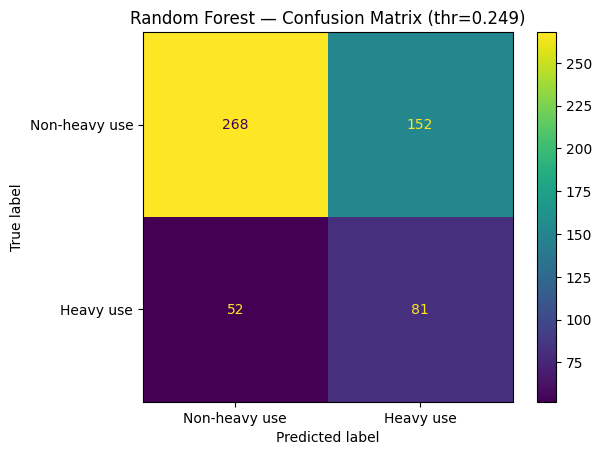

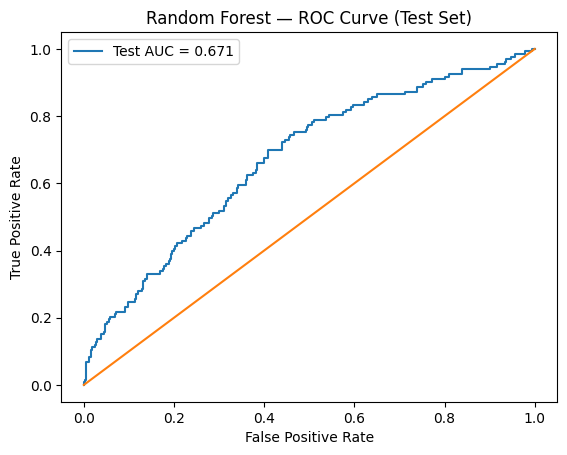

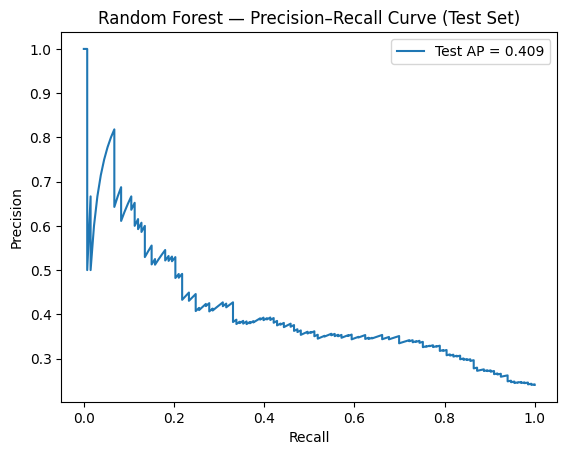

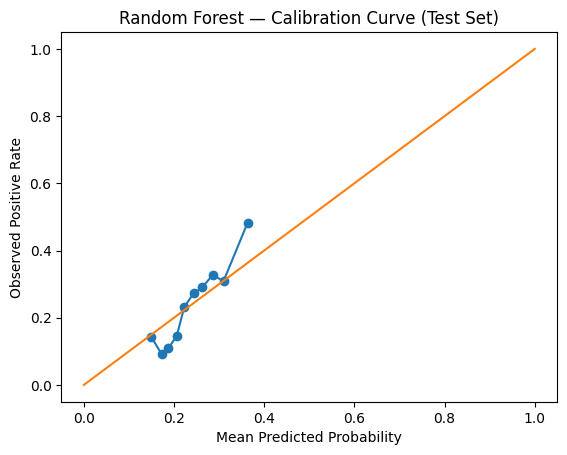

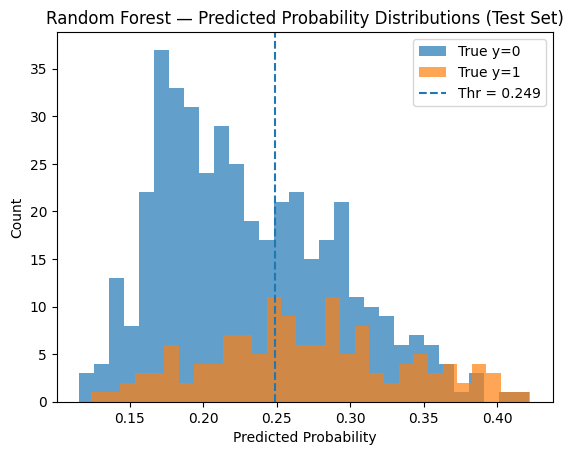


Best RF estimator:
RandomForestClassifier(bootstrap=False, max_depth=30,
                       min_impurity_decrease=0.001, min_samples_leaf=10,
                       n_estimators=300, n_jobs=-1, random_state=42)


In [18]:
# ============================================================
# RANDOM FOREST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

# Tuning CV (your preference)
cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Youden threshold CV (train-only, more stable)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# ----------------------------
# 2) TUNING SPACE (your grid + a couple of useful additions)
#    Additions:
#    - bootstrap: can affect calibration/variance
#    - min_impurity_decrease: small regularization knob (optional)
# ----------------------------
param_dist = {
    'n_estimators': [300, 500, 800, 1200, 1600],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.8, None],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'bootstrap': [True, False],
    'min_impurity_decrease': [0.0, 0.0001, 0.001]
}

rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=40,
    scoring='roc_auc',
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running RandomizedSearchCV...")
rs.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs.best_score_, 4))
print("Best Parameters:")
print(rs.best_params_)

best_rf = rs.best_estimator_  # best hyperparameters (refit=True by default)

# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY)
#    - compute OOF probabilities on TRAIN ONLY using CV=5
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_rf,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))

# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_rf.fit(X_train2, y_train)

y_prob_test = best_rf.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("RANDOM FOREST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)

# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"Random Forest — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("Random Forest — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Random Forest — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest RF estimator:")
print(best_rf)


## CatBoost

Running CatBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6367
Best Parameters (CatBoost):
{'subsample': 0.9, 'rsm': 0.6, 'random_strength': 10, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'iterations': 400, 'depth': 4, 'class_weights': [1, 5], 'bagging_temperature': 0}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.5992
Youden J (train OOF): 0.2141
Sensitivity (TPR) @ thr: 0.5779
Specificity (TNR) @ thr: 0.6362

CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6692
Test PR–AUC : 0.3944
Threshold used (Youden, from train OOF): 0.5992

Accuracy : 0.6456
Precision: 0.3600
Recall   : 0.6090
F1-score : 0.4525

Confusion Matrix (Test):
 [[276 144]
 [ 52  81]] 

Classification Report (Test):
              precision    recall  f1-score    support
0              0.841463  0.657143  0.737968  420.00000
1              0.360000  0.609023  0.452514  133.00000
accuracy       0.645570  0.645570  0.645570 

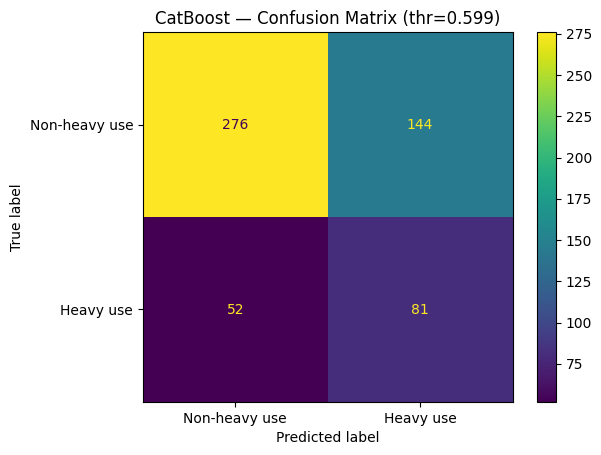

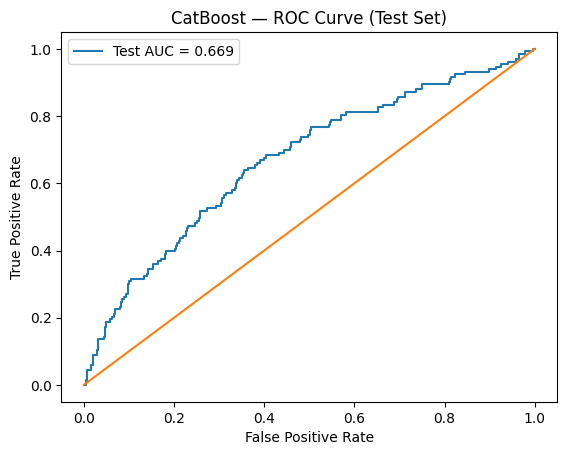

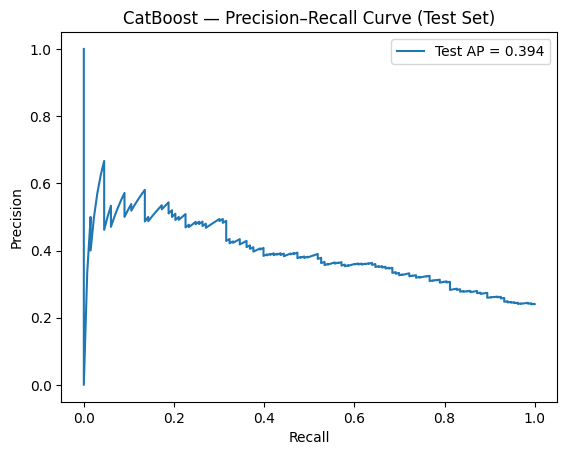

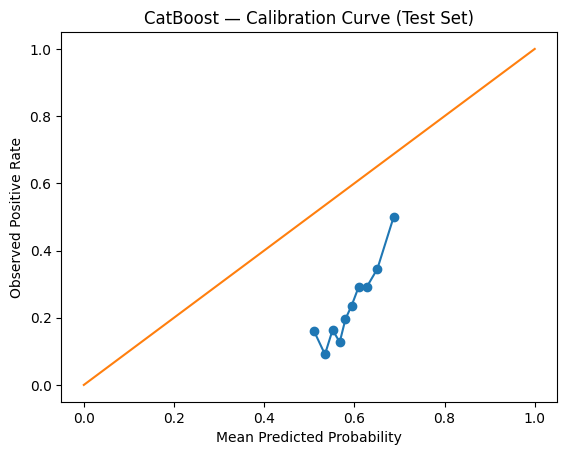

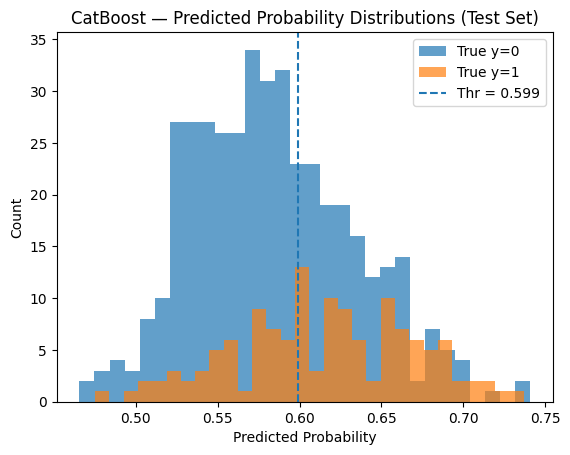


Best CatBoost estimator:


In [19]:
# ============================================================
# CATBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) SETTINGS
# ----------------------------
RANDOM_STATE = 42

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # tuning CV
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE) # threshold CV

# ----------------------------
# 1) BASE MODEL
# ----------------------------
cat = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

# ----------------------------
# 2) TUNING SPACE
#    Your grid + a couple of useful additions for generalization:
#    - rsm (feature subsampling) helps reduce overfit
#    - bagging_temperature controls bootstrap strength (esp. good for CatBoost)
# ----------------------------
param_dist_cat = {
    "iterations": [400, 800, 1200, 1600],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9, 12, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 1, 2, 5, 10],
    "bagging_temperature": [0, 1, 5, 10],
    "rsm": [0.6, 0.8, 1.0],
    # your class-weights tuning (fine)
    "class_weights": [[1, 3], [1, 5], [1, 7], [1, 10]]
}

rs_cat = RandomizedSearchCV(
    estimator=cat,
    param_distributions=param_dist_cat,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running CatBoost RandomizedSearchCV...")
rs_cat.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_cat.best_score_, 4))
print("Best Parameters (CatBoost):")
print(rs_cat.best_params_)

best_cat = rs_cat.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_cat,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_cat.fit(X_train2, y_train)

y_prob_test = best_cat.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("CATBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_cat.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"CatBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CatBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CatBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("CatBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("CatBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest CatBoost estimator:")
print(best_cat)


## XGBoost

Running XGBoost RandomizedSearchCV...
Fitting 3 folds for each of 40 candidates, totalling 120 fits

Best CV AUC (tuning, CV=3): 0.6172
Best Parameters (XGBoost):
{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 1200, 'min_child_weight': 3, 'max_depth': 5, 'max_delta_step': 1, 'learning_rate': 0.1, 'gamma': 5, 'colsample_bytree': 0.8}

YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)
Youden threshold: 0.4324
Youden J (train OOF): 0.1314
Sensitivity (TPR) @ thr: 0.5905
Specificity (TNR) @ thr: 0.5409

XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)

Test ROC–AUC: 0.6350
Test PR–AUC : 0.3448
Threshold used (Youden, from train OOF): 0.4324

Accuracy : 0.5606
Precision: 0.3154
Recall   : 0.7068
F1-score : 0.4362

Confusion Matrix (Test):
 [[216 204]
 [ 39  94]] 

Classification Report (Test):
              precision    recall  f1-score     support
0              0.847059  0.514286  0.640000  420.000000
1              0.315436  0.706767  0.436195  133.000000
accuracy       0.560579  0.5

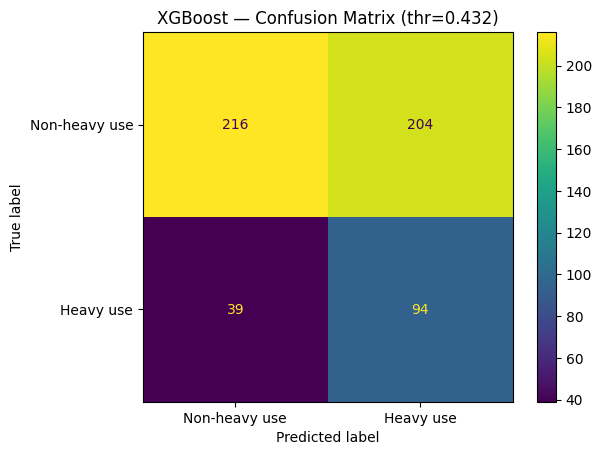

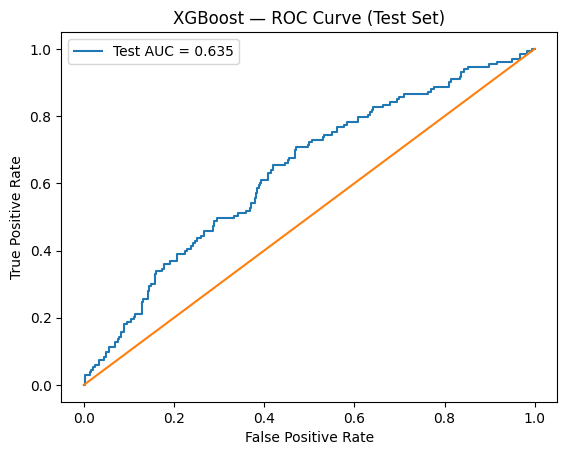

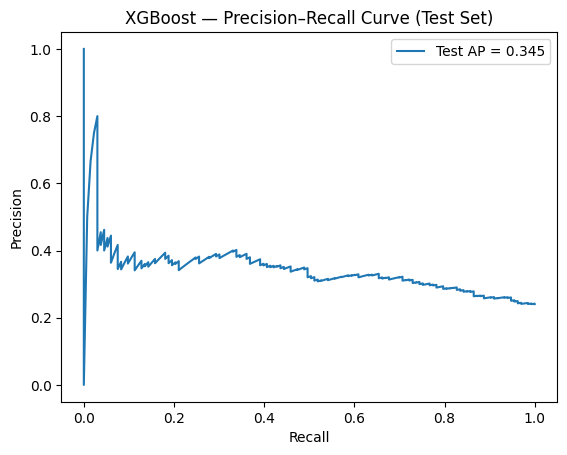

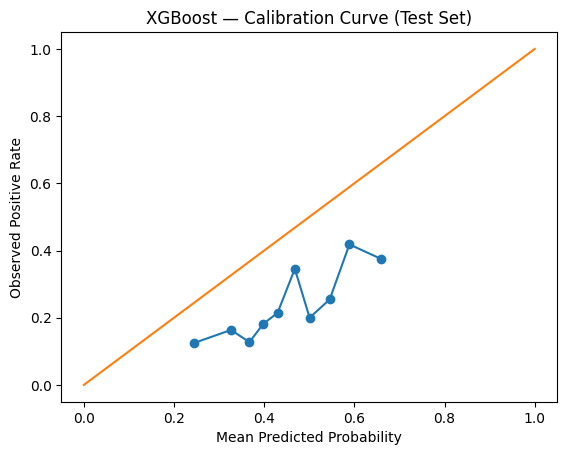

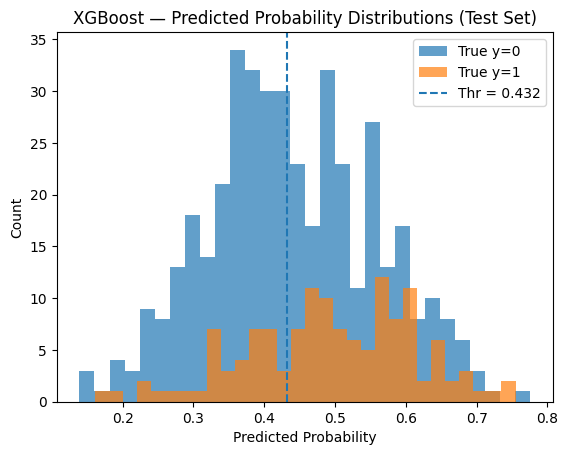


Best XGBoost estimator:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None, max_delta_step=1,
              max_depth=5, max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1200,
              n_jobs=-1, num_parallel_tree=None, ...)


In [20]:
# ============================================================
# XGBOOST — TUNING (CV=3) + YOUDEN (CORRECT: TRAIN-ONLY CV=5 OOF)
# + FINAL TEST METRICS + FIGURES (COLORED CM, ROC, PR, CALIBRATION, PROB DIST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

# ----------------------------
# 0) COPIES + IMBALANCE RATIO
# ----------------------------
X_train2 = X_train.copy()
X_test2  = X_test.copy()

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos = neg / pos

RANDOM_STATE = 42
cv_tune   = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_youden = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ----------------------------
# 1) BASE MODEL
# ----------------------------
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",          # stable for training; AUC used in CV scoring
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scale_pos_weight=scale_pos
)

# ----------------------------
# 2) TUNING SPACE (your grid + useful additions)
#    Additions:
#    - reg_lambda & reg_alpha already included (good)
#    - min_child_weight already included (good)
#    - max_delta_step sometimes stabilizes imbalanced logistic loss (optional)
# ----------------------------
param_dist_xgb = {
    "n_estimators": [300, 500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_lambda": [0.5, 1, 2, 5, 10],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "max_delta_step": [0, 1, 5]     # optional stabilizer for imbalance
}

rs_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=cv_tune,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False
)

print("Running XGBoost RandomizedSearchCV...")
rs_xgb.fit(X_train2, y_train)

print("\nBest CV AUC (tuning, CV=3):", round(rs_xgb.best_score_, 4))
print("Best Parameters (XGBoost):")
print(rs_xgb.best_params_)

best_xgb = rs_xgb.best_estimator_  # refit=True by default


# ----------------------------
# 3) YOUDEN THRESHOLD (CORRECT WAY): TRAIN ONLY, CV=5 OOF PROBS
# ----------------------------
def youden_from_probs(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    return thresholds[best_idx], youden_j[best_idx], fpr, tpr, thresholds, youden_j, best_idx

oof_prob = cross_val_predict(
    best_xgb,
    X_train2, y_train,
    cv=cv_youden,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

youden_thr, youden_j_best, fpr_oof, tpr_oof, thr_oof, youden_j_all, best_idx = youden_from_probs(y_train, oof_prob)

print("\n===============================================")
print("YOUDEN THRESHOLD (TRAIN ONLY, CV=5 OOF)")
print("===============================================")
print("Youden threshold:", round(youden_thr, 4))
print("Youden J (train OOF):", round(youden_j_best, 4))
print("Sensitivity (TPR) @ thr:", round(tpr_oof[best_idx], 4))
print("Specificity (TNR) @ thr:", round(1 - fpr_oof[best_idx], 4))


# ----------------------------
# 4) FINAL MODEL FIT ON FULL TRAIN + SINGLE TEST EVALUATION
# ----------------------------
best_xgb.fit(X_train2, y_train)

y_prob_test = best_xgb.predict_proba(X_test2)[:, 1]
y_pred_test = (y_prob_test >= youden_thr).astype(int)

test_auc = roc_auc_score(y_test, y_prob_test)
test_ap  = average_precision_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)

acc  = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec  = recall_score(y_test, y_pred_test, zero_division=0)
f1   = f1_score(y_test, y_pred_test, zero_division=0)

print("\n===============================================")
print("XGBOOST — FINAL TEST PERFORMANCE (YOUDEN)")
print("===============================================\n")
print(f"Test ROC–AUC: {test_auc:.4f}")
print(f"Test PR–AUC : {test_ap:.4f}")
print(f"Threshold used (Youden, from train OOF): {youden_thr:.4f}\n")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")

print("Confusion Matrix (Test):\n", cm, "\n")

print("Classification Report (Test):")
print(pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T)

# Summary table (handy for thesis)
summary = pd.DataFrame({
    "Metric": [
        "CV ROC–AUC (tuning, best)",
        "Youden threshold (train OOF, CV=5)",
        "Youden J (train OOF, CV=5)",
        "Test ROC–AUC",
        "Test PR–AUC",
        "Test Accuracy",
        "Test Precision (class 1)",
        "Test Recall (class 1)",
        "Test F1 (class 1)"
    ],
    "Value": [
        rs_xgb.best_score_,
        youden_thr,
        youden_j_best,
        test_auc,
        test_ap,
        acc,
        prec,
        rec,
        f1
    ]
}).round(4)

print("\nFinal Performance Summary:")
print(summary)


# ============================================================
# 5) FIGURES
# ============================================================

# 5.1 COLORED CONFUSION MATRIX (Matplotlib colormap)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-heavy use", "Heavy use"]
)
fig, ax = plt.subplots()
disp.plot(ax=ax)
ax.set_title(f"XGBoost — Confusion Matrix (thr={youden_thr:.3f})")
plt.show()

# 5.2 ROC CURVE (TEST)
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
plt.figure()
plt.plot(fpr_test, tpr_test, label=f"Test AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost — ROC Curve (Test Set)")
plt.legend()
plt.show()

# 5.3 PRECISION–RECALL CURVE (TEST)
prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_prob_test)
plt.figure()
plt.plot(rec_curve, prec_curve, label=f"Test AP = {test_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("XGBoost — Precision–Recall Curve (Test Set)")
plt.legend()
plt.show()

# 5.4 CALIBRATION CURVE (TEST)
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Rate")
plt.title("XGBoost — Calibration Curve (Test Set)")
plt.show()

# 5.5 PROBABILITY DISTRIBUTIONS (TEST) + THRESHOLD
y_test_np = np.asarray(y_test)
plt.figure()
plt.hist(y_prob_test[y_test_np == 0], bins=30, alpha=0.7, label="True y=0")
plt.hist(y_prob_test[y_test_np == 1], bins=30, alpha=0.7, label="True y=1")
plt.axvline(youden_thr, linestyle="--", label=f"Thr = {youden_thr:.3f}")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("XGBoost — Predicted Probability Distributions (Test Set)")
plt.legend()
plt.show()

print("\nBest XGBoost estimator:")
print(best_xgb)


## Plain Logistic Cutoff 4

In [241]:
df_logit=pd.read_csv('df-logit.csv')

In [242]:
import numpy as np
import pandas as pd

# =========================
# USER SETTINGS
# =========================
target = "DaysMarijuanaPast12M_W4"  
corr_thr = 0.04                      # sensible given weak correlations
pair_corr_cut = 0.80                 # multicollinearity screen

# =========================
# 0) Basic numeric-only frame + drop rows missing target
# =========================
df = df_logit.copy()

# Keep numeric predictors only (bool allowed)
numeric_cols = df.select_dtypes(include=[np.number, "bool"]).columns.tolist()

if target not in df.columns:
    raise ValueError(f"Target '{target}' not found in df_all.")

# Ensure target is numeric
if not np.issubdtype(df[target].dtype, np.number):
    df[target] = pd.to_numeric(df[target], errors="coerce")

df = df.dropna(subset=[target])

# Candidate predictors
X_cols_all = [c for c in numeric_cols if c != target]

# Drop near-zero variance columns
low_var = [c for c in X_cols_all if df[c].nunique(dropna=True) <= 1]
X_cols_all = [c for c in X_cols_all if c not in low_var]

# =========================
# 1) Filter by correlation with target
# =========================
corrs = df[X_cols_all + [target]].corr(numeric_only=True)[target].drop(target)
corrs_abs = corrs.abs().sort_values(ascending=False)

corr_keep = corrs_abs[corrs_abs >= corr_thr].index.tolist()

# Relax threshold if too few survive
if len(corr_keep) < 10 and len(corrs_abs) > 0:
    corr_thr_relaxed = max(0.01, corr_thr / 2)
    corr_keep = corrs_abs[corrs_abs >= corr_thr_relaxed].index.tolist()
    print(f"[Info] Relaxed corr threshold to {corr_thr_relaxed:.3f}")
else:
    corr_thr_relaxed = corr_thr

print(f"[Step 1] Kept {len(corr_keep)} vars with |corr| ≥ {corr_thr_relaxed:.3f}")

# =========================
# 2) Remove multicollinearity by pairwise correlation
#    (drop weaker-to-target variable)
# =========================
X_corr = df[corr_keep].corr().abs()

to_drop = set()
cols = X_corr.columns.tolist()

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        c1, c2 = cols[i], cols[j]
        if X_corr.loc[c1, c2] >= pair_corr_cut:
            # drop the weaker variable (lower |corr with target|)
            if corrs_abs[c1] >= corrs_abs[c2]:
                to_drop.add(c2)
            else:
                to_drop.add(c1)

pairwise_keep = [c for c in corr_keep if c not in to_drop]

print(f"[Step 2] Dropped {len(to_drop)} vars with pairwise |corr| ≥ {pair_corr_cut:.2f}")
print(f"[Step 2] Remaining vars: {len(pairwise_keep)}")

# =========================
# 3) Outputs
# =========================
vars_decent_corr = corr_keep
vars_low_multicollinearity = pairwise_keep

print("\n=== FINAL FEATURE SET ===")
print(f"Variables kept (n={len(vars_low_multicollinearity)}):")
for v in vars_low_multicollinearity:
    print(v)


# =========================
# 4) Filtered dataframe (NO imputation)
# =========================
df_logit = df[vars_low_multicollinearity + [target]].copy()


[Step 1] Kept 85 vars with |corr| ≥ 0.040
[Step 2] Dropped 22 vars with pairwise |corr| ≥ 0.80
[Step 2] Remaining vars: 63

=== FINAL FEATURE SET ===
Variables kept (n=63):
heavy_smoker
Trouble_GetAlong_Teachers_W1
SchoolSuspension
Sex_Female
GPA_Index
FriendsRespect_Sex
Age_FirstMarijuana
Lifetime_Marijuana
PhysicalFight_W1
SoldDrugs_Z
SawViolentAttack_W1
Fight_Serious_Z
NightAway_W1
Rev_UpsetMother_Sex_Z
ClosenessToMother_W1
WeaponThreat_W1
PeerWeed_Count
NotWorthLiving
Relax_Sex
Age_FirstCocaine
TeacherCare_W1
SchoolExpulsion
FriendCare_W1
DrugsAvailable_Home
LessLonely_Sex
GroupFight_Z
BuildingCondition
DroveWithoutPermission_Z
Age_FirstDrinkNoAdults
ExpectCollege_W1
Bills_Payment_Ability
PeerCig_Count
Age at First Drink
DrinksPerOccasion_Past12mo
StreetCondition
Attractive_Sex
HoursGames_W1
Trouble Paying Attention
HoursTV_W1
InjuredSomeone
TroubleGetAlong_Students_W1
ParentCare_W1
Rev_FeelGuilty_Sex_Z
Household_Income
ParentalSupervision_Index
NeighborhoodType_6
AdultCare_W1
Suic

In [243]:
df_logit = df_logit[df_logit["DaysMarijuanaPast12M_W4"].notna()].copy()
df_logit["heavy_smoker"] = (df_logit["DaysMarijuanaPast12M_W4"] >4 ).astype(int)

y = df_logit["heavy_smoker"]

X = df_logit.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [244]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [245]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import statsmodels.api as sm

# --- 1) TRAIN medians (store them)
train_medians = X_train.median(numeric_only=True)

# --- 2) Impute using TRAIN medians for both train and test
X_train_imp = X_train.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

# --- 3) Scale using TRAIN statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep names for statsmodels
feature_names = X_train.columns.tolist()


In [246]:
from sklearn.linear_model import LogisticRegression
lr_plain = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
lr_plain.fit(X_train_scaled, y_train)

y_pred_prob = lr_plain.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

y_pred_class = (y_pred_prob >= best_threshold).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("Optimal threshold (Youden J):", round(best_threshold, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_class))


AUC: 0.6484935437589671
Optimal threshold (Youden J): 0.142

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.52      0.66       451
           1       0.26      0.74      0.38       102

    accuracy                           0.56       553
   macro avg       0.58      0.63      0.52       553
weighted avg       0.78      0.56      0.61       553


Confusion matrix:
 [[235 216]
 [ 27  75]]


In [247]:
# Build a DataFrame so statsmodels keeps names
X_train_sm = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

logit_model = sm.Logit(y_train.astype(float), X_train_sm.astype(float))
logit_result = logit_model.fit(method="lbfgs", disp=False)

# Results table
results_table = pd.DataFrame({
    "Variable": X_train_sm.columns,
    "Coefficient": logit_result.params,
    "Std_Error": logit_result.bse,
    "p_value": logit_result.pvalues
})

results_table["Odds_Ratio"] = np.exp(results_table["Coefficient"])
results_table = results_table[results_table["Variable"] != "const"].sort_values("p_value")

results_table


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.167870,0.063324,0.008026,0.845464
GroupFight_Z,GroupFight_Z,-0.192771,0.082354,0.019244,0.824671
ClosenessToMother_W1,ClosenessToMother_W1,-0.136673,0.059812,0.022309,0.872255
NotWorthLiving,NotWorthLiving,0.143730,0.068020,0.034597,1.154573
SchoolSuspension,SchoolSuspension,0.160760,0.076716,0.036125,1.174403
...,...,...,...,...,...
Trouble Paying Attention,Trouble Paying Attention,0.010200,0.088439,0.908180,1.010252
Relax_Sex,Relax_Sex,0.004999,0.079278,0.949723,1.005011
HoursGames_W1,HoursGames_W1,0.003647,0.064604,0.954983,1.003654
Attractive_Sex,Attractive_Sex,-0.004165,0.085971,0.961357,0.995843


In [248]:
alpha = 0.05

significant_vars = results_table[
    results_table["p_value"] < alpha
].copy()

significant_vars


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.167870,0.063324,0.008026,0.845464
GroupFight_Z,GroupFight_Z,-0.192771,0.082354,0.019244,0.824671
ClosenessToMother_W1,ClosenessToMother_W1,-0.136673,0.059812,0.022309,0.872255
NotWorthLiving,NotWorthLiving,0.143730,0.068020,0.034597,1.154573
SchoolSuspension,SchoolSuspension,0.160760,0.076716,0.036125,1.174403


## Cutoff 3

In [31]:
df_logit = df_logit[df_logit["DaysMarijuanaPast12M_W4"].notna()].copy()
df_logit["heavy_smoker"] = (df_logit["DaysMarijuanaPast12M_W4"] >3 ).astype(int)

y = df_logit["heavy_smoker"]

X = df_logit.drop(columns=["DaysMarijuanaPast12M_W4", "heavy_smoker"])

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [255]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import statsmodels.api as sm

# --- 1) TRAIN medians (store them)
train_medians = X_train.median(numeric_only=True)

# --- 2) Impute using TRAIN medians for both train and test
X_train_imp = X_train.fillna(train_medians)
X_test_imp  = X_test.fillna(train_medians)

# --- 3) Scale using TRAIN statistics
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled  = scaler.transform(X_test_imp)

# Keep names for statsmodels
feature_names = X_train.columns.tolist()


In [256]:
from sklearn.linear_model import LogisticRegression
lr_plain = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000)
lr_plain.fit(X_train_scaled, y_train)

y_pred_prob = lr_plain.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

y_pred_class = (y_pred_prob >= best_threshold).astype(int)

print("AUC:", roc_auc_score(y_test, y_pred_prob))
print("Optimal threshold (Youden J):", round(best_threshold, 4))
print("\nClassification report:\n", classification_report(y_test, y_pred_class))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred_class))


AUC: 0.6430182599355531
Optimal threshold (Youden J): 0.2012

Classification report:
               precision    recall  f1-score   support

           0       0.87      0.48      0.62       420
           1       0.32      0.78      0.46       133

    accuracy                           0.55       553
   macro avg       0.60      0.63      0.54       553
weighted avg       0.74      0.55      0.58       553


Confusion matrix:
 [[200 220]
 [ 29 104]]


In [257]:
# Build a DataFrame so statsmodels keeps names
X_train_sm = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

logit_model = sm.Logit(y_train.astype(float), X_train_sm.astype(float))
logit_result = logit_model.fit(method="lbfgs", disp=False)

# Results table
results_table = pd.DataFrame({
    "Variable": X_train_sm.columns,
    "Coefficient": logit_result.params,
    "Std_Error": logit_result.bse,
    "p_value": logit_result.pvalues
})

results_table["Odds_Ratio"] = np.exp(results_table["Coefficient"])
results_table = results_table[results_table["Variable"] != "const"].sort_values("p_value")

results_table


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
Sex_Female,Sex_Female,-0.268402,0.073780,0.000275,0.764600
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.137111,0.058589,0.019272,0.871873
WorkedForPay_W1,WorkedForPay_W1,-0.137657,0.062759,0.028276,0.871398
DrugsAvailable_Home,DrugsAvailable_Home,0.120546,0.056174,0.031878,1.128113
ParentalSupervision_Index,ParentalSupervision_Index,0.129155,0.063673,0.042519,1.137867
...,...,...,...,...,...
WeaponUse_Threat_Z,WeaponUse_Threat_Z,-0.002934,0.063667,0.963249,0.997071
SoldDrugs_Z,SoldDrugs_Z,0.003130,0.070474,0.964577,1.003135
TeacherCare_W1,TeacherCare_W1,0.002544,0.070543,0.971237,1.002547
Age at First Drink,Age at First Drink,-0.002075,0.063025,0.973731,0.997927


In [258]:
alpha = 0.05

significant_vars = results_table[
    results_table["p_value"] < alpha
].copy()

significant_vars


,Variable,Coefficient,Std_Error,p_value,Odds_Ratio
Sex_Female,Sex_Female,-0.268402,0.073780,0.000275,0.764600
DrinkWithoutAdults_Z,DrinkWithoutAdults_Z,-0.137111,0.058589,0.019272,0.871873
WorkedForPay_W1,WorkedForPay_W1,-0.137657,0.062759,0.028276,0.871398
DrugsAvailable_Home,DrugsAvailable_Home,0.120546,0.056174,0.031878,1.128113
ParentalSupervision_Index,ParentalSupervision_Index,0.129155,0.063673,0.042519,1.137867
